<a href="https://colab.research.google.com/github/tpiedrahita-byte/sys2025/blob/main/modulacion_toeria_de_se%C3%B1ales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_269/3205123172.py:195: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pot_estimada_2 = np.trapz(P2, f2)
/tmp/ipykernel_269/3205123172.py:196: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pot_obj_2 = np.trapz(psd_obj2, f_obj2)


Resumen de reconstrucción con mezclas gaussianas:

Modelo 1 – Ruido blanco
  Mejor K = 12
  Error relativo mínimo = 0.325055
  Componentes gaussianas usadas (peso, mu, sigma):
    pi = 2.25313e-03, mu = 264.706, sigma = 20.444
    pi = 1.93615e-03, mu = 470.588, sigma = 20.444
    pi = 1.74453e-03, mu = 411.765, sigma = 20.444
    pi = 1.68388e-03, mu = 29.412, sigma = 20.444
    pi = 1.50210e-03, mu = 205.882, sigma = 20.444
    pi = 1.29623e-03, mu = 117.647, sigma = 32.889
    pi = 1.26833e-03, mu = 323.529, sigma = 20.444
    pi = 1.20177e-03, mu = 88.235, sigma = 8.000
    pi = 1.13011e-03, mu = 176.471, sigma = 20.444
    pi = 9.46491e-04, mu = 382.353, sigma = 20.444
    pi = 8.91232e-04, mu = 58.824, sigma = 8.000
    pi = 7.62451e-04, mu = 323.529, sigma = 8.000

Modelo 2 – PSD gaussiana
  Mejor K = 12
  Error relativo mínimo = 0.194417
  Componentes gaussianas usadas (peso, mu, sigma):
    pi = 6.68277e-03, mu = 29.412, sigma = 20.444
    pi = 3.80737e-03, mu = 88.235, sigma 

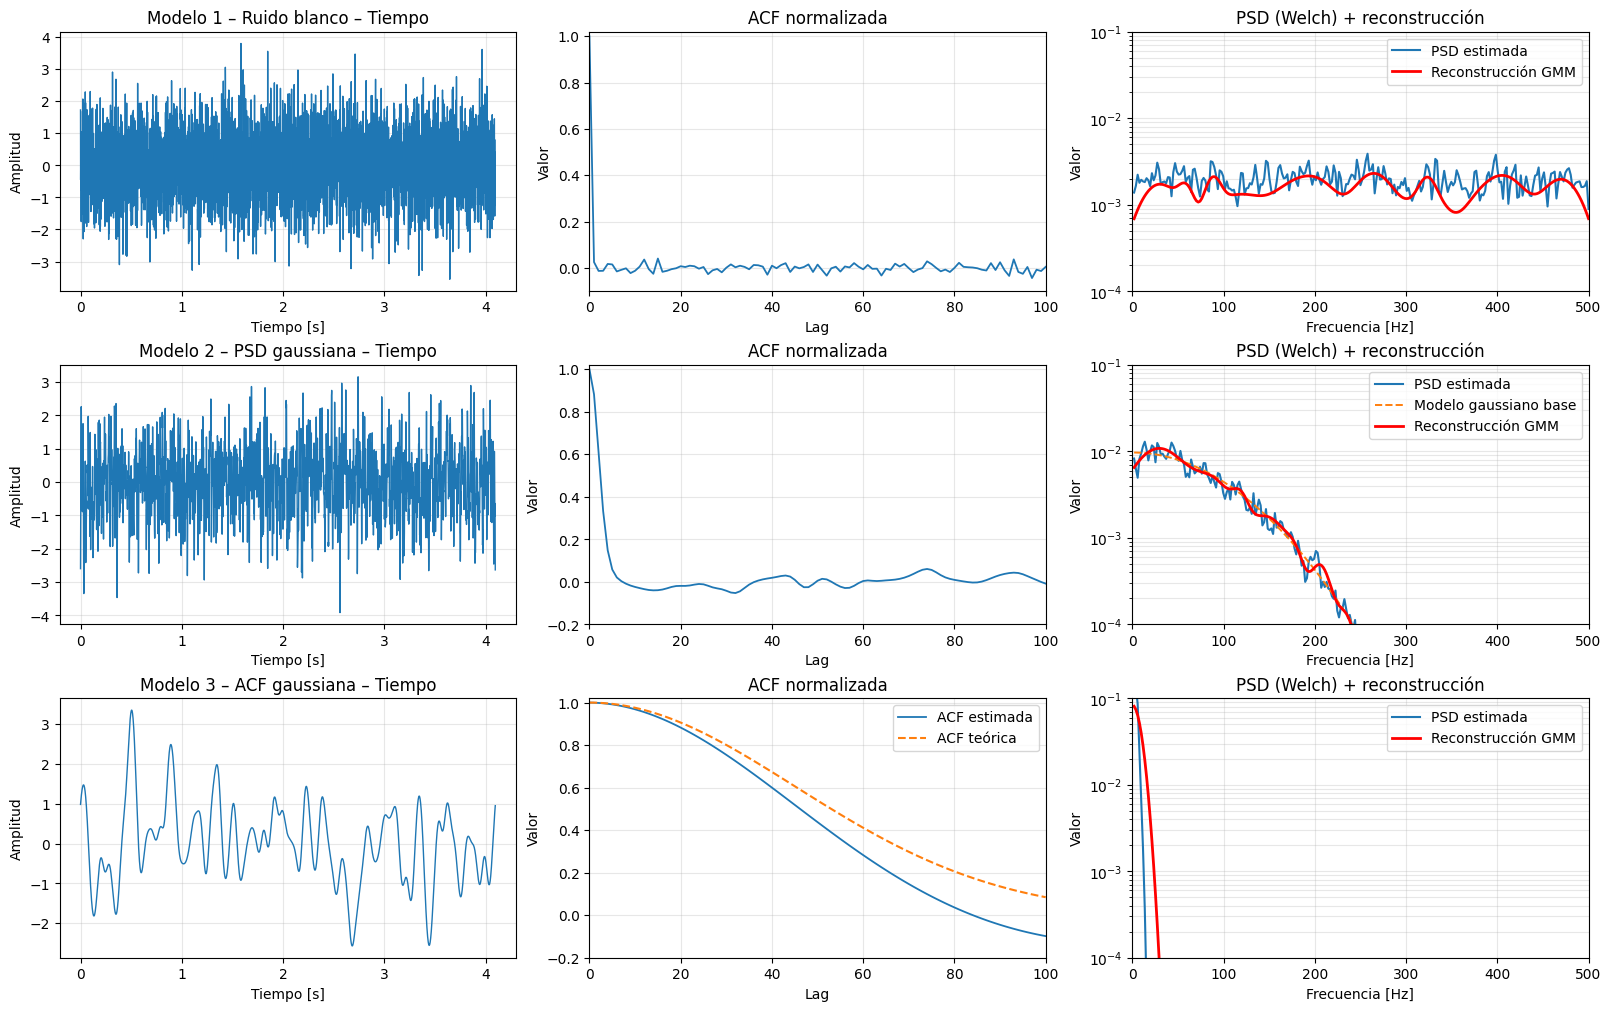

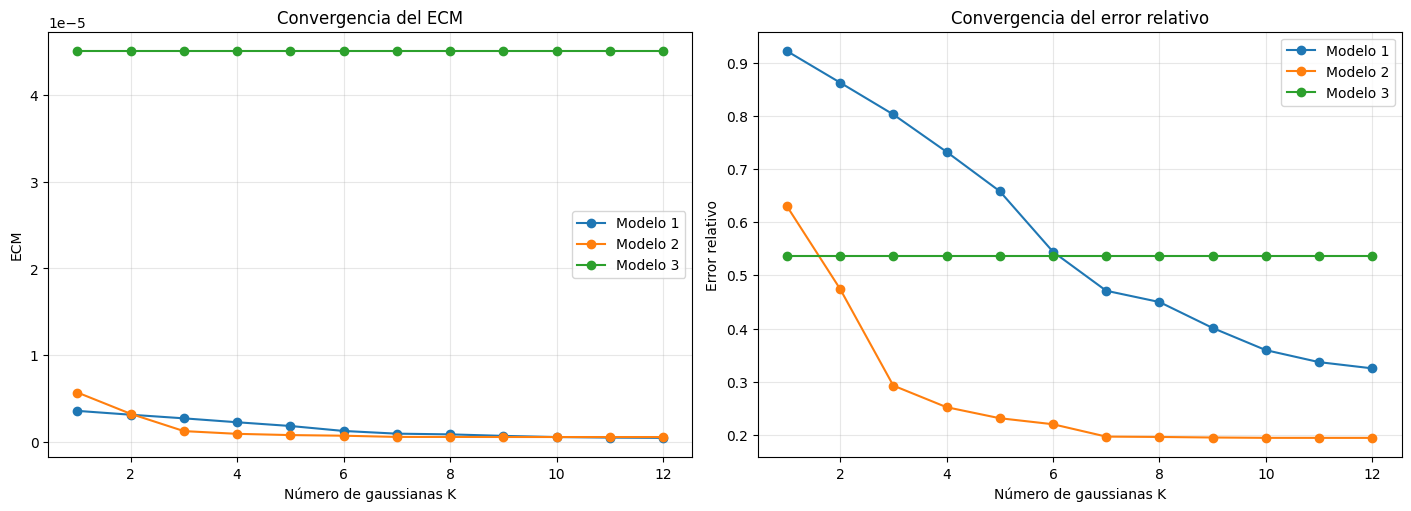

Resumen estadístico de los tres modelos:

Modelo 1 – Ruido blanco
  media               = 0.000000
  varianza            = 1.000000
  potencia estimada   = 0.987628

Modelo 2 – PSD gaussiana
  media               = 0.000000
  varianza            = 1.000000
  potencia estimada   = 0.975198
  sigma_f             = 80.000 Hz

Modelo 3 – ACF gaussiana
  media               = 0.000000
  varianza            = 1.000000
  potencia estimada   = 0.747799
  sigma_r             = 45.000 retardos


/tmp/ipykernel_269/3205123172.py:403: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  potencia estimada   = {np.trapz(P1, f1):.6f}\n")
/tmp/ipykernel_269/3205123172.py:408: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  potencia estimada   = {np.trapz(P2, f2):.6f}")
/tmp/ipykernel_269/3205123172.py:414: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  potencia estimada   = {np.trapz(P3, f3):.6f}")


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.optimize import nnls

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================
np.random.seed(7)

N = 4096
fs = 1000.0
mu = 0.0
varianza_objetivo = 1.0
sigma_objetivo = np.sqrt(varianza_objetivo)

t = np.arange(N) / fs

# Parámetros gaussianos de los modelos
sigma_f = 80.0          # dispersión espectral para el modelo con PSD gaussiana
sigma_r = 45.0          # dispersión en retardos para el modelo con ACF gaussiana

# Parámetros para reconstrucción con mezclas gaussianas
K_MAX = 12
NUM_CENTROS = 18
NUM_SIGMAS = 10
SIGMA_MIN = 8.0
SIGMA_MAX = 120.0

# =========================================================
# FUNCIONES AUXILIARES
# =========================================================
def normalizar_media_varianza(x, media=0.0, varianza=1.0):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)
    std = np.std(x)
    if std < 1e-12:
        raise ValueError("La desviación estándar es demasiado pequeña para normalizar.")
    x = x / std
    x = x * np.sqrt(varianza) + media
    return x

def estimar_psd_welch(x, fs, nperseg=512):
    f, Pxx = welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend="constant",
        scaling="density",
        return_onesided=True,
    )
    return f, Pxx

def autocorrelacion_normalizada_positiva(x):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)
    r = np.correlate(x, x, mode="full")
    centro = len(r) // 2
    r = r[centro:]
    if np.abs(r[0]) < 1e-14:
        raise ValueError("No se puede normalizar la autocorrelación porque r[0] es casi cero.")
    r = r / r[0]
    lags = np.arange(len(r))
    return lags, r

def gaussiana_1d(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# =========================================================
# DICCIONARIO DE MEZCLAS GAUSSIANAS PARA RECONSTRUIR PSD
# p(f|theta) = sum_k pi_k N(f|mu_k, sigma_k^2)
# =========================================================
def construir_diccionario_mezclas(frecuencias, num_centros=18, num_sigmas=10, sigma_min=8.0, sigma_max=120.0):
    fmax = np.max(frecuencias)
    centros = np.linspace(0.0, fmax, num_centros)
    sigmas = np.linspace(sigma_min, sigma_max, num_sigmas)

    columnas = []
    parametros = []

    for mu_k in centros:
        for sigma_k in sigmas:
            base = gaussiana_1d(frecuencias, mu_k, sigma_k)
            columnas.append(base)
            parametros.append((mu_k, sigma_k))

    D = np.column_stack(columnas)
    return D, parametros

def reconstruir_psd_mezcla_gaussiana(frecuencias, Pxx, K_max=12, num_centros=18, num_sigmas=10, sigma_min=8.0, sigma_max=120.0):
    """
    Reconstruye una PSD como mezcla de gaussianas:
    S_hat(f) = sum_k pi_k * N(f | mu_k, sigma_k^2), con pi_k >= 0
    """
    frecuencias = np.asarray(frecuencias, dtype=np.float64)
    Pxx = np.asarray(Pxx, dtype=np.float64)

    D, params = construir_diccionario_mezclas(
        frecuencias,
        num_centros=num_centros,
        num_sigmas=num_sigmas,
        sigma_min=sigma_min,
        sigma_max=sigma_max,
    )

    # Normalización por columnas para estabilizar NNLS
    normas = np.linalg.norm(D, axis=0) + 1e-14
    Dn = D / normas

    # Ajuste inicial con todo el diccionario
    pesos_norm_all, _ = nnls(Dn, Pxx)
    pesos_all = pesos_norm_all / normas

    # Ordenamos componentes por importancia
    ranking = np.argsort(pesos_all)[::-1]

    errores_mse = []
    errores_rel = []
    reconstrucciones = []
    componentes = []

    for K in range(1, K_max + 1):
        idx = ranking[:K]
        Dk = D[:, idx]
        pesos_k = pesos_all[idx]

        Pxx_hat = Dk @ pesos_k

        mse = np.mean((Pxx - Pxx_hat) ** 2)
        err_rel = np.linalg.norm(Pxx - Pxx_hat) / (np.linalg.norm(Pxx) + 1e-14)

        errores_mse.append(mse)
        errores_rel.append(err_rel)
        reconstrucciones.append(Pxx_hat)
        componentes.append({
            "indices": idx,
            "pesos": pesos_k,
            "parametros": [params[i] for i in idx]
        })

    mejor_idx = int(np.argmin(errores_rel))

    return {
        "errores_mse": np.array(errores_mse),
        "errores_rel": np.array(errores_rel),
        "reconstrucciones": reconstrucciones,
        "componentes": componentes,
        "mejor_K": mejor_idx + 1,
        "mejor_reconstruccion": reconstrucciones[mejor_idx],
        "mejores_componentes": componentes[mejor_idx],
    }

# =========================================================
# MODELO 1: RUIDO BLANCO CONVENCIONAL
# =========================================================
x1 = np.random.normal(loc=mu, scale=sigma_objetivo, size=N)
x1 = normalizar_media_varianza(x1, media=0.0, varianza=1.0)

# =========================================================
# MODELO 2: RUIDO CON PSD GAUSSIANA
# PSD(f) = exp( - f^2 / (2 sigma_f^2) )
# =========================================================
f_fft = np.fft.fftfreq(N, d=1/fs)
psd_objetivo_completa = np.exp(-0.5 * (f_fft / sigma_f) ** 2)

W = np.fft.fft(np.random.normal(0, 1, N))
X2 = W * np.sqrt(psd_objetivo_completa)
x2 = np.fft.ifft(X2).real
x2 = normalizar_media_varianza(x2, media=0.0, varianza=1.0)

# =========================================================
# MODELO 3: RUIDO CON ACF GAUSSIANA
# FT de una gaussiana -> otra gaussiana
# =========================================================
psd_para_acf_gauss = np.exp(-2.0 * (np.pi**2) * ((sigma_r / fs) ** 2) * (f_fft ** 2))

W3 = np.fft.fft(np.random.normal(0, 1, N))
X3 = W3 * np.sqrt(psd_para_acf_gauss)
x3 = np.fft.ifft(X3).real
x3 = normalizar_media_varianza(x3, media=0.0, varianza=1.0)

# =========================================================
# PSD ESTIMADAS
# =========================================================
f1, P1 = estimar_psd_welch(x1, fs)
f2, P2 = estimar_psd_welch(x2, fs)
f3, P3 = estimar_psd_welch(x3, fs)

# PSD objetivo del modelo 2 para comparación
f_obj2 = f2.copy()
psd_obj2 = np.exp(-0.5 * (f_obj2 / sigma_f) ** 2)

pot_estimada_2 = np.trapz(P2, f2)
pot_obj_2 = np.trapz(psd_obj2, f_obj2)
psd_obj2 = psd_obj2 * (pot_estimada_2 / (pot_obj_2 + 1e-14))

# =========================================================
# AUTOCORRELACIONES NORMALIZADAS
# =========================================================
lags1, r1 = autocorrelacion_normalizada_positiva(x1)
lags2, r2 = autocorrelacion_normalizada_positiva(x2)
lags3, r3 = autocorrelacion_normalizada_positiva(x3)

lags_teo = np.arange(len(r3))
r3_teorica = np.exp(-0.5 * (lags_teo / sigma_r) ** 2)

# =========================================================
# RECONSTRUCCIÓN DE CADA PSD CON MEZCLAS GAUSSIANAS
# =========================================================
rec1 = reconstruir_psd_mezcla_gaussiana(
    f1, P1,
    K_max=K_MAX,
    num_centros=NUM_CENTROS,
    num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
)

rec2 = reconstruir_psd_mezcla_gaussiana(
    f2, P2,
    K_max=K_MAX,
    num_centros=NUM_CENTROS,
    num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
)

rec3 = reconstruir_psd_mezcla_gaussiana(
    f3, P3,
    K_max=K_MAX,
    num_centros=NUM_CENTROS,
    num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
)

P1_rec = rec1["mejor_reconstruccion"]
P2_rec = rec2["mejor_reconstruccion"]
P3_rec = rec3["mejor_reconstruccion"]

# =========================================================
# INFORMACIÓN SOBRE LAS MEZCLAS GAUSSIANAS
# =========================================================
print("Resumen de reconstrucción con mezclas gaussianas:\n")

for nombre, rec in zip(
    ["Modelo 1 – Ruido blanco", "Modelo 2 – PSD gaussiana", "Modelo 3 – ACF gaussiana"],
    [rec1, rec2, rec3]
):
    print(nombre)
    print(f"  Mejor K = {rec['mejor_K']}")
    print(f"  Error relativo mínimo = {rec['errores_rel'][rec['mejor_K'] - 1]:.6f}")
    print("  Componentes gaussianas usadas (peso, mu, sigma):")
    for peso, (mu_k, sigma_k) in zip(rec["mejores_componentes"]["pesos"], rec["mejores_componentes"]["parametros"]):
        print(f"    pi = {peso:.5e}, mu = {mu_k:.3f}, sigma = {sigma_k:.3f}")
    print()

# =========================================================
# RANGO DE VISUALIZACIÓN
# =========================================================
mask1 = f1 > 0
mask2 = f2 > 0
mask3 = f3 > 0

max_lag_plot = 100
lags1_plot = lags1[:max_lag_plot + 1]
lags2_plot = lags2[:max_lag_plot + 1]
lags3_plot = lags3[:max_lag_plot + 1]

r1_plot = r1[:max_lag_plot + 1]
r2_plot = r2[:max_lag_plot + 1]
r3_plot = r3[:max_lag_plot + 1]
r3_teorica_plot = r3_teorica[:max_lag_plot + 1]

# =========================================================
# GRÁFICAS PRINCIPALES
# =========================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 10), constrained_layout=True)

# ---------------------------------------------------------
# FILA 1: MODELO 1
# ---------------------------------------------------------
axes[0, 0].plot(t, x1, linewidth=1.0)
axes[0, 0].set_title("Modelo 1 – Ruido blanco – Tiempo")
axes[0, 0].set_xlabel("Tiempo [s]")
axes[0, 0].set_ylabel("Amplitud")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(lags1_plot, r1_plot, linewidth=1.3)
axes[0, 1].set_title("ACF normalizada")
axes[0, 1].set_xlabel("Lag")
axes[0, 1].set_ylabel("Valor")
axes[0, 1].set_xlim(0, 100)
axes[0, 1].set_ylim(-0.1, 1.02)
axes[0, 1].grid(alpha=0.3)

axes[0, 2].semilogy(f1[mask1], P1[mask1], linewidth=1.5, label="PSD estimada")
axes[0, 2].semilogy(f1[mask1], P1_rec[mask1], color="red", linewidth=2.0, label="Reconstrucción GMM")
axes[0, 2].set_title("PSD (Welch) + reconstrucción")
axes[0, 2].set_xlabel("Frecuencia [Hz]")
axes[0, 2].set_ylabel("Valor")
axes[0, 2].set_xlim(0, fs / 2)
axes[0, 2].set_ylim(1e-4, 1e-1)
axes[0, 2].grid(alpha=0.3, which="both")
axes[0, 2].legend()

# ---------------------------------------------------------
# FILA 2: MODELO 2
# ---------------------------------------------------------
axes[1, 0].plot(t, x2, linewidth=1.0)
axes[1, 0].set_title("Modelo 2 – PSD gaussiana – Tiempo")
axes[1, 0].set_xlabel("Tiempo [s]")
axes[1, 0].set_ylabel("Amplitud")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(lags2_plot, r2_plot, linewidth=1.3)
axes[1, 1].set_title("ACF normalizada")
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylabel("Valor")
axes[1, 1].set_xlim(0, 100)
axes[1, 1].set_ylim(-0.2, 1.02)
axes[1, 1].grid(alpha=0.3)

axes[1, 2].semilogy(f2[mask2], P2[mask2], linewidth=1.5, label="PSD estimada")
axes[1, 2].semilogy(f2[mask2], psd_obj2[mask2], "--", linewidth=1.4, label="Modelo gaussiano base")
axes[1, 2].semilogy(f2[mask2], P2_rec[mask2], color="red", linewidth=2.0, label="Reconstrucción GMM")
axes[1, 2].set_title("PSD (Welch) + reconstrucción")
axes[1, 2].set_xlabel("Frecuencia [Hz]")
axes[1, 2].set_ylabel("Valor")
axes[1, 2].set_xlim(0, fs / 2)
axes[1, 2].set_ylim(1e-4, 1e-1)
axes[1, 2].grid(alpha=0.3, which="both")
axes[1, 2].legend()

# ---------------------------------------------------------
# FILA 3: MODELO 3
# ---------------------------------------------------------
axes[2, 0].plot(t, x3, linewidth=1.0)
axes[2, 0].set_title("Modelo 3 – ACF gaussiana – Tiempo")
axes[2, 0].set_xlabel("Tiempo [s]")
axes[2, 0].set_ylabel("Amplitud")
axes[2, 0].grid(alpha=0.3)

axes[2, 1].plot(lags3_plot, r3_plot, linewidth=1.3, label="ACF estimada")
axes[2, 1].plot(lags3_plot, r3_teorica_plot, "--", linewidth=1.5, label="ACF teórica")
axes[2, 1].set_title("ACF normalizada")
axes[2, 1].set_xlabel("Lag")
axes[2, 1].set_ylabel("Valor")
axes[2, 1].set_xlim(0, 100)
axes[2, 1].set_ylim(-0.2, 1.02)
axes[2, 1].grid(alpha=0.3)
axes[2, 1].legend()

axes[2, 2].semilogy(f3[mask3], P3[mask3], linewidth=1.5, label="PSD estimada")
axes[2, 2].semilogy(f3[mask3], P3_rec[mask3], color="red", linewidth=2.0, label="Reconstrucción GMM")
axes[2, 2].set_title("PSD (Welch) + reconstrucción")
axes[2, 2].set_xlabel("Frecuencia [Hz]")
axes[2, 2].set_ylabel("Valor")
axes[2, 2].set_xlim(0, fs / 2)
axes[2, 2].set_ylim(1e-4, 1e-1)
axes[2, 2].grid(alpha=0.3, which="both")
axes[2, 2].legend()

plt.show()

# =========================================================
# GRÁFICAS DE CONVERGENCIA DEL ERROR
# =========================================================
Ks = np.arange(1, K_MAX + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

ax[0].plot(Ks, rec1["errores_mse"], marker="o", linewidth=1.5, label="Modelo 1")
ax[0].plot(Ks, rec2["errores_mse"], marker="o", linewidth=1.5, label="Modelo 2")
ax[0].plot(Ks, rec3["errores_mse"], marker="o", linewidth=1.5, label="Modelo 3")
ax[0].set_title("Convergencia del ECM")
ax[0].set_xlabel("Número de gaussianas K")
ax[0].set_ylabel("ECM")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(Ks, rec1["errores_rel"], marker="o", linewidth=1.5, label="Modelo 1")
ax[1].plot(Ks, rec2["errores_rel"], marker="o", linewidth=1.5, label="Modelo 2")
ax[1].plot(Ks, rec3["errores_rel"], marker="o", linewidth=1.5, label="Modelo 3")
ax[1].set_title("Convergencia del error relativo")
ax[1].set_xlabel("Número de gaussianas K")
ax[1].set_ylabel("Error relativo")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.show()

# =========================================================
# RESUMEN NUMÉRICO
# =========================================================
print("Resumen estadístico de los tres modelos:\n")

print("Modelo 1 – Ruido blanco")
print(f"  media               = {np.mean(x1):.6f}")
print(f"  varianza            = {np.var(x1):.6f}")
print(f"  potencia estimada   = {np.trapz(P1, f1):.6f}\n")

print("Modelo 2 – PSD gaussiana")
print(f"  media               = {np.mean(x2):.6f}")
print(f"  varianza            = {np.var(x2):.6f}")
print(f"  potencia estimada   = {np.trapz(P2, f2):.6f}")
print(f"  sigma_f             = {sigma_f:.3f} Hz\n")

print("Modelo 3 – ACF gaussiana")
print(f"  media               = {np.mean(x3):.6f}")
print(f"  varianza            = {np.var(x3):.6f}")
print(f"  potencia estimada   = {np.trapz(P3, f3):.6f}")
print(f"  sigma_r             = {sigma_r:.3f} retardos")

/tmp/ipykernel_269/3613669295.py:193: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pot_estimada_2 = np.trapz(P2, f2)
/tmp/ipykernel_269/3613669295.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pot_obj_2 = np.trapz(psd_obj2, f_obj2)


Resumen de reconstrucción con mezclas gaussianas:

Modelo 1 – Ruido blanco
  Mejor K = 15
  Error relativo mínimo = 0.333872
  Componentes usadas (peso, mu, sigma):
    pi = 2.12725e-03, mu = 260.870, sigma = 20.444
    pi = 1.86781e-03, mu = 43.478, sigma = 20.444
    pi = 1.61729e-03, mu = 347.826, sigma = 20.444
    pi = 1.46758e-03, mu = 456.522, sigma = 20.444
    pi = 1.44579e-03, mu = 413.043, sigma = 20.444
    pi = 1.37037e-03, mu = 152.174, sigma = 20.444
    pi = 1.34270e-03, mu = 86.957, sigma = 8.000
    pi = 1.33504e-03, mu = 108.696, sigma = 20.444
    pi = 1.30125e-03, mu = 217.391, sigma = 8.000
    pi = 1.13640e-03, mu = 0.000, sigma = 20.444
    pi = 9.81929e-04, mu = 195.652, sigma = 8.000
    pi = 9.30203e-04, mu = 304.348, sigma = 20.444
    pi = 8.69731e-04, mu = 326.087, sigma = 8.000
    pi = 8.66467e-04, mu = 173.913, sigma = 20.444
    pi = 7.88727e-04, mu = 478.261, sigma = 8.000

Modelo 2 – PSD gaussiana centrada en el medio
  Mejor K = 15
  Error relativo 

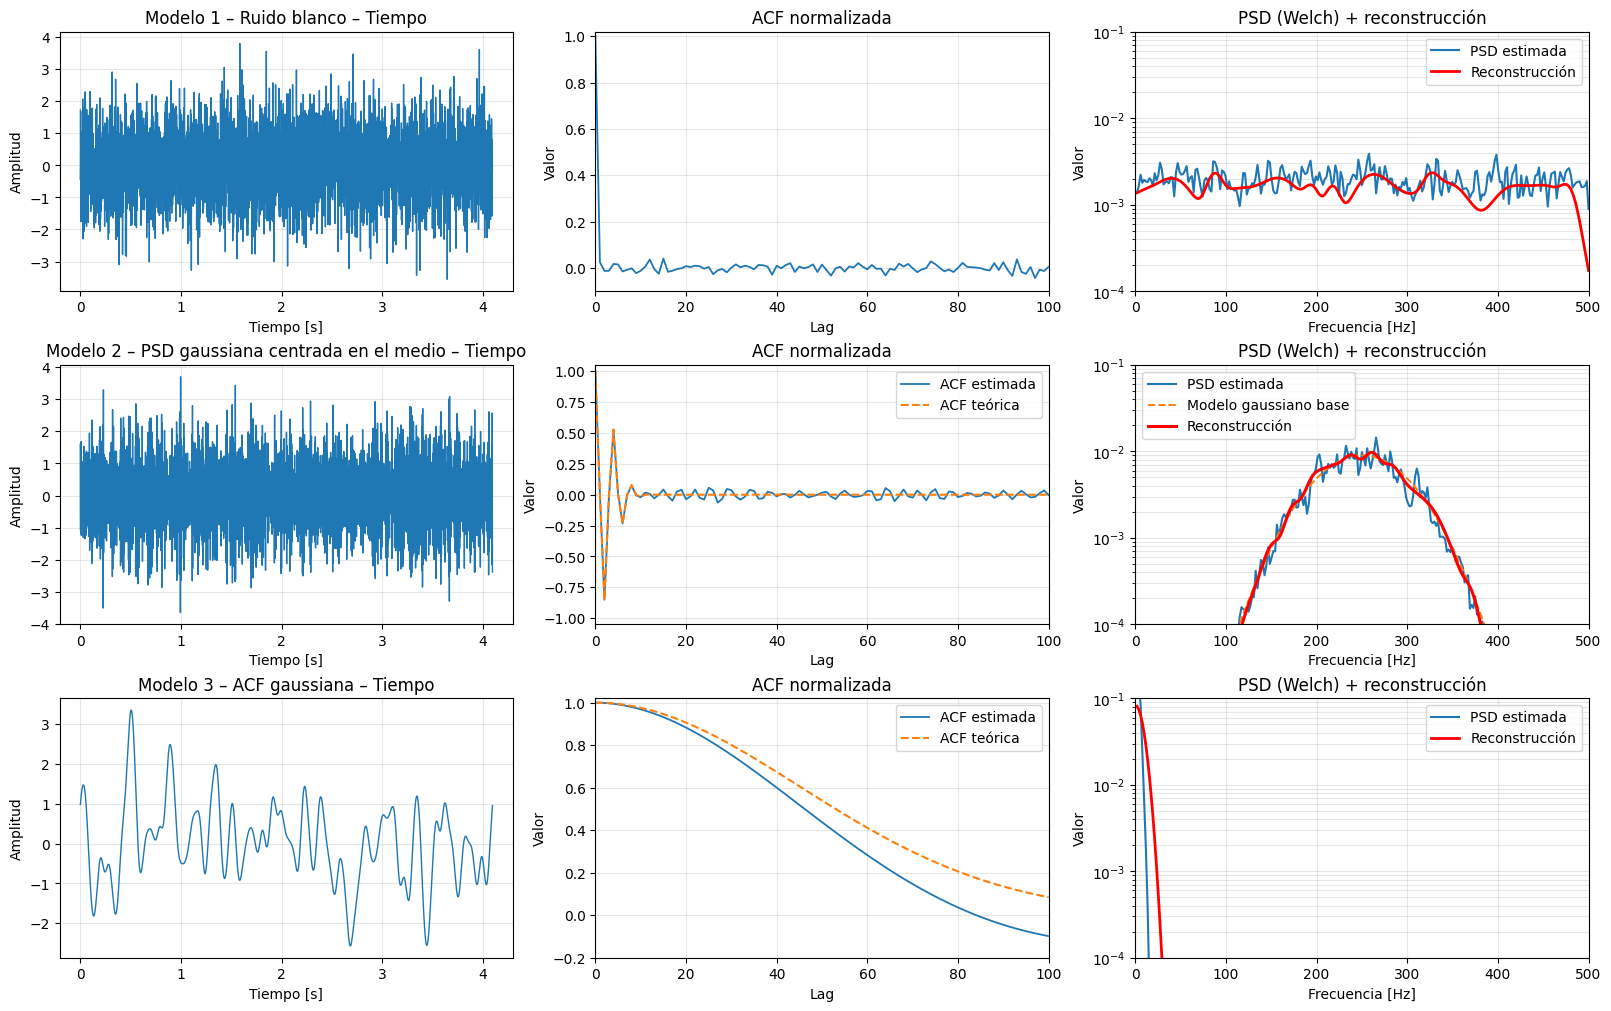

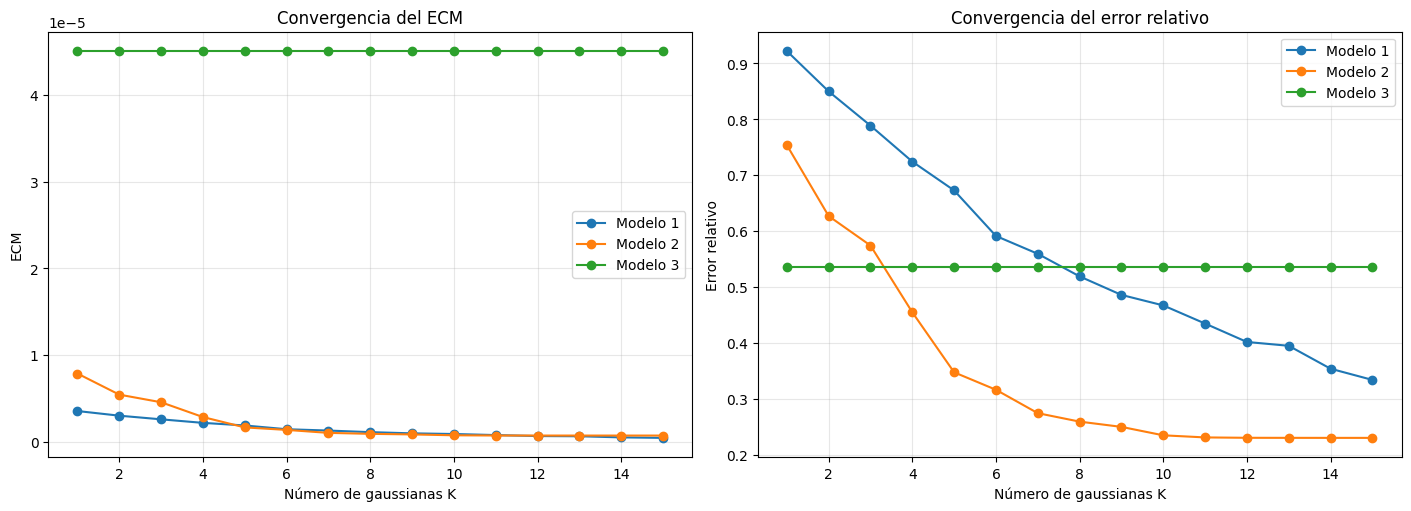

Resumen estadístico de los tres modelos:

Modelo 1 – Ruido blanco
  media               = 0.000000
  varianza            = 1.000000
  potencia estimada   = 0.987628

Modelo 2 – PSD gaussiana centrada en el medio
  media               = 0.000000
  varianza            = 1.000000
  potencia estimada   = 1.020032
  frecuencia central  = 250.000 Hz
  sigma_f             = 45.000 Hz
  mezclas necesarias  = 15

Modelo 3 – ACF gaussiana
  media               = 0.000000
  varianza            = 1.000000
  potencia estimada   = 0.747799
  sigma_r             = 45.000 retardos


/tmp/ipykernel_269/3613669295.py:417: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  potencia estimada   = {np.trapz(P1, f1):.6f}\n")
/tmp/ipykernel_269/3613669295.py:422: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  potencia estimada   = {np.trapz(P2, f2):.6f}")
/tmp/ipykernel_269/3613669295.py:430: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  potencia estimada   = {np.trapz(P3, f3):.6f}")


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.optimize import nnls

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================
np.random.seed(7)

N = 4096
fs = 1000.0
mu = 0.0
varianza_objetivo = 1.0
sigma_objetivo = np.sqrt(varianza_objetivo)

t = np.arange(N) / fs

# Parámetros gaussianos
sigma_f = 45.0                 # ancho espectral de la gaussiana
f_centro = fs / 4              # gaussiana centrada en la mitad del eje positivo (250 Hz)
sigma_r = 45.0                 # dispersión en retardos para el modelo 3

# Parámetros para reconstrucción por mezclas gaussianas
K_MAX = 15
NUM_CENTROS = 24
NUM_SIGMAS = 10
SIGMA_MIN = 8.0
SIGMA_MAX = 120.0

# =========================================================
# FUNCIONES AUXILIARES
# =========================================================
def normalizar_media_varianza(x, media=0.0, varianza=1.0):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)
    std = np.std(x)
    if std < 1e-12:
        raise ValueError("La desviación estándar es demasiado pequeña para normalizar.")
    x = x / std
    x = x * np.sqrt(varianza) + media
    return x

def estimar_psd_welch(x, fs, nperseg=512):
    f, Pxx = welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend="constant",
        scaling="density",
        return_onesided=True,
    )
    return f, Pxx

def autocorrelacion_normalizada_positiva(x):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)
    r = np.correlate(x, x, mode="full")
    centro = len(r) // 2
    r = r[centro:]
    if np.abs(r[0]) < 1e-14:
        raise ValueError("No se puede normalizar la autocorrelación porque r[0] es casi cero.")
    r = r / r[0]
    lags = np.arange(len(r))
    return lags, r

def gaussiana_1d(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# =========================================================
# DICCIONARIO DE MEZCLAS GAUSSIANAS PARA RECONSTRUIR PSD
# S_hat(f) = sum_k pi_k N(f | mu_k, sigma_k^2), con pi_k >= 0
# =========================================================
def construir_diccionario_mezclas(frecuencias, num_centros=24, num_sigmas=10, sigma_min=8.0, sigma_max=120.0):
    fmax = np.max(frecuencias)
    centros = np.linspace(0.0, fmax, num_centros)
    sigmas = np.linspace(sigma_min, sigma_max, num_sigmas)

    columnas = []
    parametros = []

    for mu_k in centros:
        for sigma_k in sigmas:
            base = gaussiana_1d(frecuencias, mu_k, sigma_k)
            columnas.append(base)
            parametros.append((mu_k, sigma_k))

    D = np.column_stack(columnas)
    return D, parametros

def reconstruir_psd_mezcla_gaussiana(frecuencias, Pxx, K_max=15, num_centros=24, num_sigmas=10, sigma_min=8.0, sigma_max=120.0):
    frecuencias = np.asarray(frecuencias, dtype=np.float64)
    Pxx = np.asarray(Pxx, dtype=np.float64)

    D, params = construir_diccionario_mezclas(
        frecuencias,
        num_centros=num_centros,
        num_sigmas=num_sigmas,
        sigma_min=sigma_min,
        sigma_max=sigma_max,
    )

    normas = np.linalg.norm(D, axis=0) + 1e-14
    Dn = D / normas

    pesos_norm_all, _ = nnls(Dn, Pxx)
    pesos_all = pesos_norm_all / normas

    ranking = np.argsort(pesos_all)[::-1]

    errores_mse = []
    errores_rel = []
    reconstrucciones = []
    componentes = []

    for K in range(1, K_max + 1):
        idx = ranking[:K]
        Dk = D[:, idx]
        pesos_k = pesos_all[idx]

        Pxx_hat = Dk @ pesos_k

        mse = np.mean((Pxx - Pxx_hat) ** 2)
        err_rel = np.linalg.norm(Pxx - Pxx_hat) / (np.linalg.norm(Pxx) + 1e-14)

        errores_mse.append(mse)
        errores_rel.append(err_rel)
        reconstrucciones.append(Pxx_hat)
        componentes.append({
            "indices": idx,
            "pesos": pesos_k,
            "parametros": [params[i] for i in idx]
        })

    mejor_idx = int(np.argmin(errores_rel))

    return {
        "errores_mse": np.array(errores_mse),
        "errores_rel": np.array(errores_rel),
        "reconstrucciones": reconstrucciones,
        "componentes": componentes,
        "mejor_K": mejor_idx + 1,
        "mejor_reconstruccion": reconstrucciones[mejor_idx],
        "mejores_componentes": componentes[mejor_idx],
    }

# =========================================================
# MODELO 1: RUIDO BLANCO
# =========================================================
x1 = np.random.normal(loc=mu, scale=sigma_objetivo, size=N)
x1 = normalizar_media_varianza(x1, media=0.0, varianza=1.0)

# =========================================================
# MODELO 2: PSD GAUSSIANA CENTRADA EN EL MEDIO
# PSD(f) = exp(-(f-f0)^2 / (2 sigma_f^2))
# Se construye simétrica en frecuencia para obtener señal real
# =========================================================
f_fft = np.fft.fftfreq(N, d=1/fs)
psd_objetivo_completa = (
    np.exp(-0.5 * ((f_fft - f_centro) / sigma_f) ** 2) +
    np.exp(-0.5 * ((f_fft + f_centro) / sigma_f) ** 2)
)

W = np.fft.fft(np.random.normal(0, 1, N))
X2 = W * np.sqrt(psd_objetivo_completa)
x2 = np.fft.ifft(X2).real
x2 = normalizar_media_varianza(x2, media=0.0, varianza=1.0)

# =========================================================
# MODELO 3: RUIDO CON ACF GAUSSIANA
# =========================================================
psd_para_acf_gauss = np.exp(-2.0 * (np.pi**2) * ((sigma_r / fs) ** 2) * (f_fft ** 2))

W3 = np.fft.fft(np.random.normal(0, 1, N))
X3 = W3 * np.sqrt(psd_para_acf_gauss)
x3 = np.fft.ifft(X3).real
x3 = normalizar_media_varianza(x3, media=0.0, varianza=1.0)

# =========================================================
# PSD ESTIMADAS
# =========================================================
f1, P1 = estimar_psd_welch(x1, fs)
f2, P2 = estimar_psd_welch(x2, fs)
f3, P3 = estimar_psd_welch(x3, fs)

# PSD objetivo del modelo 2 en frecuencias positivas
f_obj2 = f2.copy()
psd_obj2 = np.exp(-0.5 * ((f_obj2 - f_centro) / sigma_f) ** 2)

# Escalamiento de potencia para comparación
pot_estimada_2 = np.trapz(P2, f2)
pot_obj_2 = np.trapz(psd_obj2, f_obj2)
psd_obj2 = psd_obj2 * (pot_estimada_2 / (pot_obj_2 + 1e-14))

# =========================================================
# AUTOCORRELACIONES
# =========================================================
lags1, r1 = autocorrelacion_normalizada_positiva(x1)
lags2, r2 = autocorrelacion_normalizada_positiva(x2)
lags3, r3 = autocorrelacion_normalizada_positiva(x3)

# ACF teórica del modelo 2:
# una gaussiana desplazada en frecuencia produce una
# autocorrelación tipo gaussiana modulada por coseno
lags_teo2 = np.arange(len(r2))
r2_teorica = np.exp(-0.5 * (lags_teo2 / (fs / (2*np.pi*sigma_f)))**2) * np.cos(2*np.pi*f_centro*lags_teo2/fs)
r2_teorica = r2_teorica / r2_teorica[0]

# ACF teórica del modelo 3
lags_teo3 = np.arange(len(r3))
r3_teorica = np.exp(-0.5 * (lags_teo3 / sigma_r) ** 2)

# =========================================================
# RECONSTRUCCIÓN DE LAS PSD CON MEZCLAS GAUSSIANAS
# =========================================================
rec1 = reconstruir_psd_mezcla_gaussiana(
    f1, P1,
    K_max=K_MAX,
    num_centros=NUM_CENTROS,
    num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
)

rec2 = reconstruir_psd_mezcla_gaussiana(
    f2, P2,
    K_max=K_MAX,
    num_centros=NUM_CENTROS,
    num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
)

rec3 = reconstruir_psd_mezcla_gaussiana(
    f3, P3,
    K_max=K_MAX,
    num_centros=NUM_CENTROS,
    num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
)

P1_rec = rec1["mejor_reconstruccion"]
P2_rec = rec2["mejor_reconstruccion"]
P3_rec = rec3["mejor_reconstruccion"]

# =========================================================
# INFORMACIÓN DE LAS MEZCLAS
# =========================================================
print("Resumen de reconstrucción con mezclas gaussianas:\n")

for nombre, rec in zip(
    ["Modelo 1 – Ruido blanco", "Modelo 2 – PSD gaussiana centrada en el medio", "Modelo 3 – ACF gaussiana"],
    [rec1, rec2, rec3]
):
    print(nombre)
    print(f"  Mejor K = {rec['mejor_K']}")
    print(f"  Error relativo mínimo = {rec['errores_rel'][rec['mejor_K'] - 1]:.6f}")
    print("  Componentes usadas (peso, mu, sigma):")
    for peso, (mu_k, sigma_k) in zip(rec["mejores_componentes"]["pesos"], rec["mejores_componentes"]["parametros"]):
        print(f"    pi = {peso:.5e}, mu = {mu_k:.3f}, sigma = {sigma_k:.3f}")
    print()

print("Cambio en la fila 2 columna 3:")
print(f"  La gaussiana ahora está centrada en f0 = {f_centro:.2f} Hz")
print(f"  La ACF deja de ser una gaussiana simple y pasa a ser una gaussiana modulada")
print(f"  Número de mezclas gaussianas requeridas para el Modelo 2 = {rec2['mejor_K']}\n")

# =========================================================
# RANGO DE VISUALIZACIÓN
# =========================================================
mask1 = f1 > 0
mask2 = f2 > 0
mask3 = f3 > 0

max_lag_plot = 100
lags1_plot = lags1[:max_lag_plot + 1]
lags2_plot = lags2[:max_lag_plot + 1]
lags3_plot = lags3[:max_lag_plot + 1]

r1_plot = r1[:max_lag_plot + 1]
r2_plot = r2[:max_lag_plot + 1]
r3_plot = r3[:max_lag_plot + 1]
r2_teorica_plot = r2_teorica[:max_lag_plot + 1]
r3_teorica_plot = r3_teorica[:max_lag_plot + 1]

# =========================================================
# GRÁFICAS PRINCIPALES
# =========================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 10), constrained_layout=True)

# ---------------------------------------------------------
# FILA 1: MODELO 1
# ---------------------------------------------------------
axes[0, 0].plot(t, x1, linewidth=1.0)
axes[0, 0].set_title("Modelo 1 – Ruido blanco – Tiempo")
axes[0, 0].set_xlabel("Tiempo [s]")
axes[0, 0].set_ylabel("Amplitud")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(lags1_plot, r1_plot, linewidth=1.3)
axes[0, 1].set_title("ACF normalizada")
axes[0, 1].set_xlabel("Lag")
axes[0, 1].set_ylabel("Valor")
axes[0, 1].set_xlim(0, 100)
axes[0, 1].set_ylim(-0.1, 1.02)
axes[0, 1].grid(alpha=0.3)

axes[0, 2].semilogy(f1[mask1], P1[mask1], linewidth=1.5, label="PSD estimada")
axes[0, 2].semilogy(f1[mask1], P1_rec[mask1], color="red", linewidth=2.0, label="Reconstrucción")
axes[0, 2].set_title("PSD (Welch) + reconstrucción")
axes[0, 2].set_xlabel("Frecuencia [Hz]")
axes[0, 2].set_ylabel("Valor")
axes[0, 2].set_xlim(0, fs / 2)
axes[0, 2].set_ylim(1e-4, 1e-1)
axes[0, 2].grid(alpha=0.3, which="both")
axes[0, 2].legend()

# ---------------------------------------------------------
# FILA 2: MODELO 2
# ---------------------------------------------------------
axes[1, 0].plot(t, x2, linewidth=1.0)
axes[1, 0].set_title("Modelo 2 – PSD gaussiana centrada en el medio – Tiempo")
axes[1, 0].set_xlabel("Tiempo [s]")
axes[1, 0].set_ylabel("Amplitud")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(lags2_plot, r2_plot, linewidth=1.3, label="ACF estimada")
axes[1, 1].plot(lags2_plot, r2_teorica_plot, "--", linewidth=1.5, label="ACF teórica")
axes[1, 1].set_title("ACF normalizada")
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylabel("Valor")
axes[1, 1].set_xlim(0, 100)
axes[1, 1].set_ylim(-1.05, 1.05)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

axes[1, 2].semilogy(f2[mask2], P2[mask2], linewidth=1.5, label="PSD estimada")
axes[1, 2].semilogy(f2[mask2], psd_obj2[mask2], "--", linewidth=1.4, label="Modelo gaussiano base")
axes[1, 2].semilogy(f2[mask2], P2_rec[mask2], color="red", linewidth=2.2, label="Reconstrucción")
axes[1, 2].set_title("PSD (Welch) + reconstrucción")
axes[1, 2].set_xlabel("Frecuencia [Hz]")
axes[1, 2].set_ylabel("Valor")
axes[1, 2].set_xlim(0, fs / 2)
axes[1, 2].set_ylim(1e-4, 1e-1)
axes[1, 2].grid(alpha=0.3, which="both")
axes[1, 2].legend()

# ---------------------------------------------------------
# FILA 3: MODELO 3
# ---------------------------------------------------------
axes[2, 0].plot(t, x3, linewidth=1.0)
axes[2, 0].set_title("Modelo 3 – ACF gaussiana – Tiempo")
axes[2, 0].set_xlabel("Tiempo [s]")
axes[2, 0].set_ylabel("Amplitud")
axes[2, 0].grid(alpha=0.3)

axes[2, 1].plot(lags3_plot, r3_plot, linewidth=1.3, label="ACF estimada")
axes[2, 1].plot(lags3_plot, r3_teorica_plot, "--", linewidth=1.5, label="ACF teórica")
axes[2, 1].set_title("ACF normalizada")
axes[2, 1].set_xlabel("Lag")
axes[2, 1].set_ylabel("Valor")
axes[2, 1].set_xlim(0, 100)
axes[2, 1].set_ylim(-0.2, 1.02)
axes[2, 1].grid(alpha=0.3)
axes[2, 1].legend()

axes[2, 2].semilogy(f3[mask3], P3[mask3], linewidth=1.5, label="PSD estimada")
axes[2, 2].semilogy(f3[mask3], P3_rec[mask3], color="red", linewidth=2.0, label="Reconstrucción")
axes[2, 2].set_title("PSD (Welch) + reconstrucción")
axes[2, 2].set_xlabel("Frecuencia [Hz]")
axes[2, 2].set_ylabel("Valor")
axes[2, 2].set_xlim(0, fs / 2)
axes[2, 2].set_ylim(1e-4, 1e-1)
axes[2, 2].grid(alpha=0.3, which="both")
axes[2, 2].legend()

plt.show()

# =========================================================
# GRÁFICAS DE CONVERGENCIA DEL ERROR
# =========================================================
Ks = np.arange(1, K_MAX + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

ax[0].plot(Ks, rec1["errores_mse"], marker="o", linewidth=1.5, label="Modelo 1")
ax[0].plot(Ks, rec2["errores_mse"], marker="o", linewidth=1.5, label="Modelo 2")
ax[0].plot(Ks, rec3["errores_mse"], marker="o", linewidth=1.5, label="Modelo 3")
ax[0].set_title("Convergencia del ECM")
ax[0].set_xlabel("Número de gaussianas K")
ax[0].set_ylabel("ECM")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(Ks, rec1["errores_rel"], marker="o", linewidth=1.5, label="Modelo 1")
ax[1].plot(Ks, rec2["errores_rel"], marker="o", linewidth=1.5, label="Modelo 2")
ax[1].plot(Ks, rec3["errores_rel"], marker="o", linewidth=1.5, label="Modelo 3")
ax[1].set_title("Convergencia del error relativo")
ax[1].set_xlabel("Número de gaussianas K")
ax[1].set_ylabel("Error relativo")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.show()

# =========================================================
# RESUMEN NUMÉRICO
# =========================================================
print("Resumen estadístico de los tres modelos:\n")

print("Modelo 1 – Ruido blanco")
print(f"  media               = {np.mean(x1):.6f}")
print(f"  varianza            = {np.var(x1):.6f}")
print(f"  potencia estimada   = {np.trapz(P1, f1):.6f}\n")

print("Modelo 2 – PSD gaussiana centrada en el medio")
print(f"  media               = {np.mean(x2):.6f}")
print(f"  varianza            = {np.var(x2):.6f}")
print(f"  potencia estimada   = {np.trapz(P2, f2):.6f}")
print(f"  frecuencia central  = {f_centro:.3f} Hz")
print(f"  sigma_f             = {sigma_f:.3f} Hz")
print(f"  mezclas necesarias  = {rec2['mejor_K']}\n")

print("Modelo 3 – ACF gaussiana")
print(f"  media               = {np.mean(x3):.6f}")
print(f"  varianza            = {np.var(x3):.6f}")
print(f"  potencia estimada   = {np.trapz(P3, f3):.6f}")
print(f"  sigma_r             = {sigma_r:.3f} retardos")

/tmp/ipykernel_269/2015580727.py:193: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pot_estimada_2 = np.trapz(P2, f2)
/tmp/ipykernel_269/2015580727.py:194: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pot_obj_2 = np.trapz(psd_obj2, f_obj2)


Resumen de reconstrucción con mezclas gaussianas:

Modelo 1 – Ruido blanco
  Mejor K = 15
  Error relativo mínimo = 0.333872
  Componentes usadas (peso, mu, sigma):
    pi = 2.12725e-03, mu = 260.870, sigma = 20.444
    pi = 1.86781e-03, mu = 43.478, sigma = 20.444
    pi = 1.61729e-03, mu = 347.826, sigma = 20.444
    pi = 1.46758e-03, mu = 456.522, sigma = 20.444
    pi = 1.44579e-03, mu = 413.043, sigma = 20.444
    pi = 1.37037e-03, mu = 152.174, sigma = 20.444
    pi = 1.34270e-03, mu = 86.957, sigma = 8.000
    pi = 1.33504e-03, mu = 108.696, sigma = 20.444
    pi = 1.30125e-03, mu = 217.391, sigma = 8.000
    pi = 1.13640e-03, mu = 0.000, sigma = 20.444
    pi = 9.81929e-04, mu = 195.652, sigma = 8.000
    pi = 9.30203e-04, mu = 304.348, sigma = 20.444
    pi = 8.69731e-04, mu = 326.087, sigma = 8.000
    pi = 8.66467e-04, mu = 173.913, sigma = 20.444
    pi = 7.88727e-04, mu = 478.261, sigma = 8.000

Modelo 2 – PSD gaussiana centrada en el medio
  Mejor K = 15
  Error relativo 

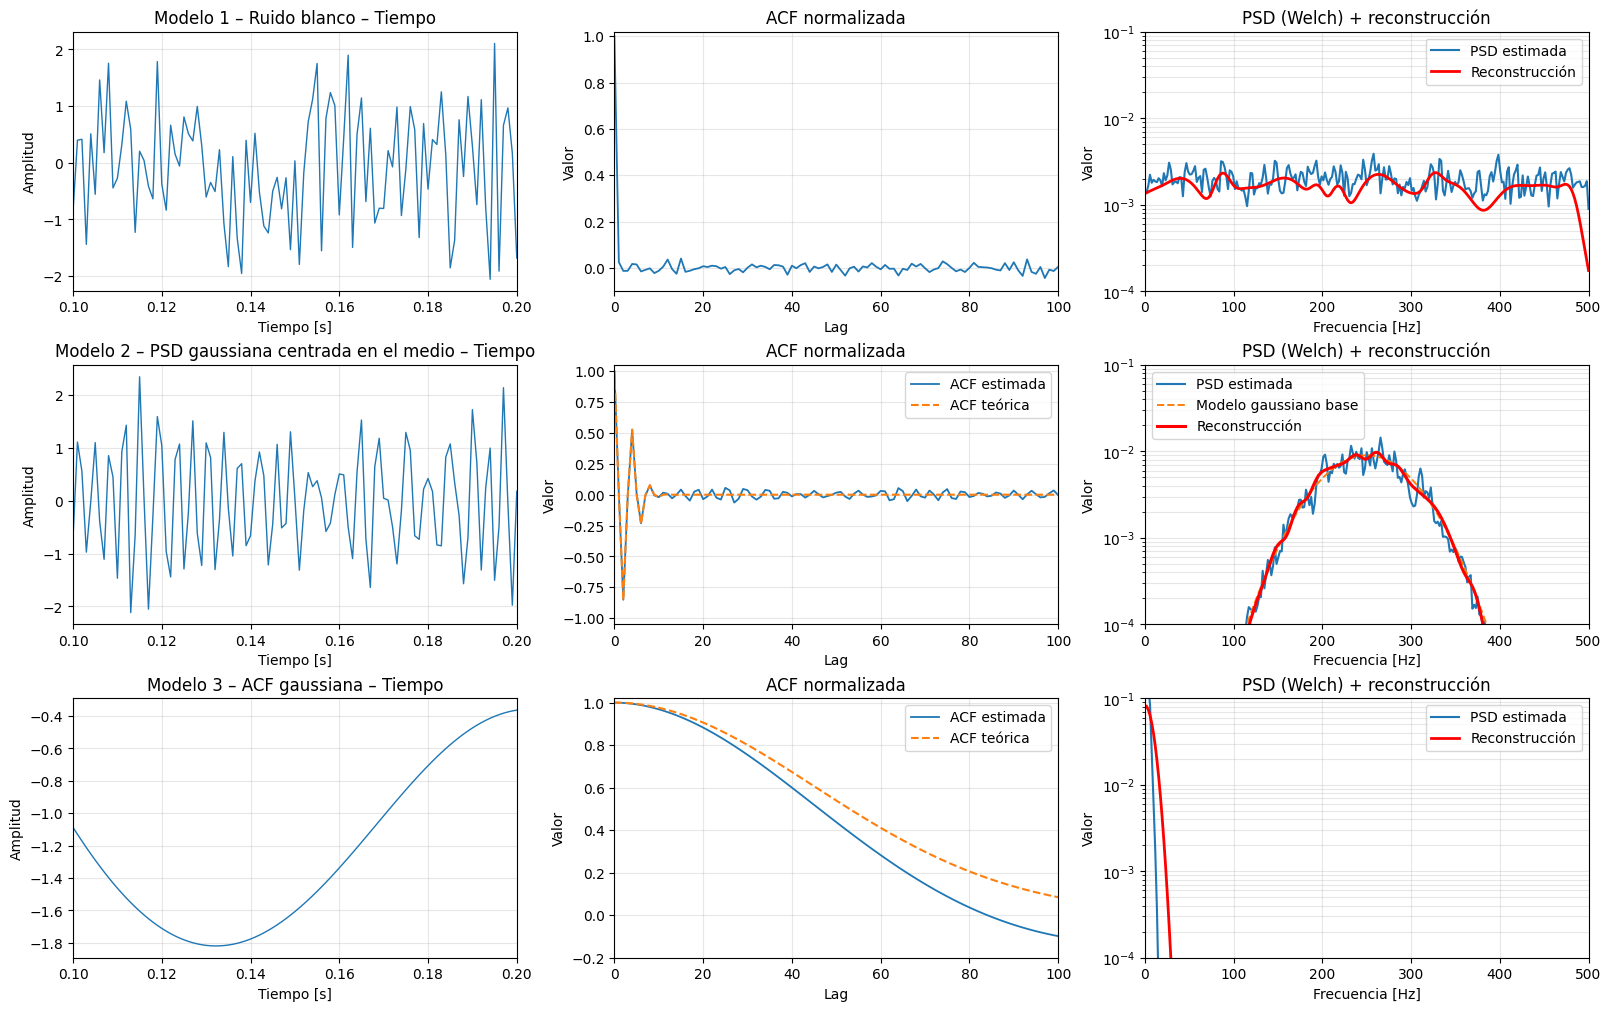

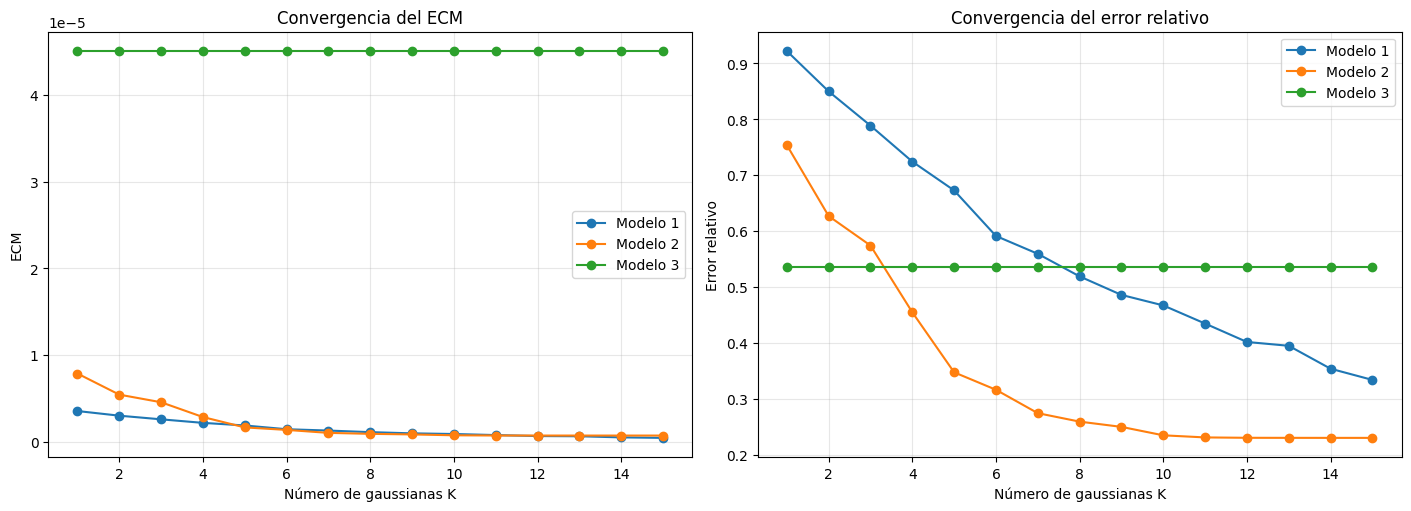

Resumen estadístico de los tres modelos:

Modelo 1 – Ruido blanco
  media               = 0.000000
  varianza            = 1.000000
  potencia estimada   = 0.987628

Modelo 2 – PSD gaussiana centrada en el medio
  media               = 0.000000
  varianza            = 1.000000
  potencia estimada   = 1.020032
  frecuencia central  = 250.000 Hz
  sigma_f             = 45.000 Hz
  mezclas necesarias  = 15

Modelo 3 – ACF gaussiana
  media               = 0.000000
  varianza            = 1.000000
  potencia estimada   = 0.747799
  sigma_r             = 45.000 retardos


/tmp/ipykernel_269/2015580727.py:409: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  potencia estimada   = {np.trapz(P1, f1):.6f}\n")
/tmp/ipykernel_269/2015580727.py:414: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  potencia estimada   = {np.trapz(P2, f2):.6f}")
/tmp/ipykernel_269/2015580727.py:422: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  potencia estimada   = {np.trapz(P3, f3):.6f}")


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.optimize import nnls

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================
np.random.seed(7)

N = 4096
fs = 1000.0
mu = 0.0
varianza_objetivo = 1.0
sigma_objetivo = np.sqrt(varianza_objetivo)

t = np.arange(N) / fs

# Ventana temporal que se quiere visualizar
t_ini = 0.1
t_fin = 0.2
mask_t = (t >= t_ini) & (t <= t_fin)

# Parámetros gaussianos
sigma_f = 45.0
f_centro = fs / 4
sigma_r = 45.0

# Parámetros para reconstrucción por mezclas gaussianas
K_MAX = 15
NUM_CENTROS = 24
NUM_SIGMAS = 10
SIGMA_MIN = 8.0
SIGMA_MAX = 120.0

# =========================================================
# FUNCIONES AUXILIARES
# =========================================================
def normalizar_media_varianza(x, media=0.0, varianza=1.0):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)
    std = np.std(x)
    if std < 1e-12:
        raise ValueError("La desviación estándar es demasiado pequeña para normalizar.")
    x = x / std
    x = x * np.sqrt(varianza) + media
    return x

def estimar_psd_welch(x, fs, nperseg=512):
    f, Pxx = welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend="constant",
        scaling="density",
        return_onesided=True,
    )
    return f, Pxx

def autocorrelacion_normalizada_positiva(x):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)
    r = np.correlate(x, x, mode="full")
    centro = len(r) // 2
    r = r[centro:]
    if np.abs(r[0]) < 1e-14:
        raise ValueError("No se puede normalizar la autocorrelación porque r[0] es casi cero.")
    r = r / r[0]
    lags = np.arange(len(r))
    return lags, r

def gaussiana_1d(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# =========================================================
# DICCIONARIO DE MEZCLAS GAUSSIANAS PARA RECONSTRUIR PSD
# =========================================================
def construir_diccionario_mezclas(frecuencias, num_centros=24, num_sigmas=10, sigma_min=8.0, sigma_max=120.0):
    fmax = np.max(frecuencias)
    centros = np.linspace(0.0, fmax, num_centros)
    sigmas = np.linspace(sigma_min, sigma_max, num_sigmas)

    columnas = []
    parametros = []

    for mu_k in centros:
        for sigma_k in sigmas:
            base = gaussiana_1d(frecuencias, mu_k, sigma_k)
            columnas.append(base)
            parametros.append((mu_k, sigma_k))

    D = np.column_stack(columnas)
    return D, parametros

def reconstruir_psd_mezcla_gaussiana(frecuencias, Pxx, K_max=15, num_centros=24, num_sigmas=10, sigma_min=8.0, sigma_max=120.0):
    frecuencias = np.asarray(frecuencias, dtype=np.float64)
    Pxx = np.asarray(Pxx, dtype=np.float64)

    D, params = construir_diccionario_mezclas(
        frecuencias,
        num_centros=num_centros,
        num_sigmas=num_sigmas,
        sigma_min=sigma_min,
        sigma_max=sigma_max,
    )

    normas = np.linalg.norm(D, axis=0) + 1e-14
    Dn = D / normas

    pesos_norm_all, _ = nnls(Dn, Pxx)
    pesos_all = pesos_norm_all / normas

    ranking = np.argsort(pesos_all)[::-1]

    errores_mse = []
    errores_rel = []
    reconstrucciones = []
    componentes = []

    for K in range(1, K_max + 1):
        idx = ranking[:K]
        Dk = D[:, idx]
        pesos_k = pesos_all[idx]

        Pxx_hat = Dk @ pesos_k

        mse = np.mean((Pxx - Pxx_hat) ** 2)
        err_rel = np.linalg.norm(Pxx - Pxx_hat) / (np.linalg.norm(Pxx) + 1e-14)

        errores_mse.append(mse)
        errores_rel.append(err_rel)
        reconstrucciones.append(Pxx_hat)
        componentes.append({
            "indices": idx,
            "pesos": pesos_k,
            "parametros": [params[i] for i in idx]
        })

    mejor_idx = int(np.argmin(errores_rel))

    return {
        "errores_mse": np.array(errores_mse),
        "errores_rel": np.array(errores_rel),
        "reconstrucciones": reconstrucciones,
        "componentes": componentes,
        "mejor_K": mejor_idx + 1,
        "mejor_reconstruccion": reconstrucciones[mejor_idx],
        "mejores_componentes": componentes[mejor_idx],
    }

# =========================================================
# MODELO 1: RUIDO BLANCO
# =========================================================
x1 = np.random.normal(loc=mu, scale=sigma_objetivo, size=N)
x1 = normalizar_media_varianza(x1, media=0.0, varianza=1.0)

# =========================================================
# MODELO 2: PSD GAUSSIANA CENTRADA EN EL MEDIO
# =========================================================
f_fft = np.fft.fftfreq(N, d=1/fs)
psd_objetivo_completa = (
    np.exp(-0.5 * ((f_fft - f_centro) / sigma_f) ** 2) +
    np.exp(-0.5 * ((f_fft + f_centro) / sigma_f) ** 2)
)

W = np.fft.fft(np.random.normal(0, 1, N))
X2 = W * np.sqrt(psd_objetivo_completa)
x2 = np.fft.ifft(X2).real
x2 = normalizar_media_varianza(x2, media=0.0, varianza=1.0)

# =========================================================
# MODELO 3: RUIDO CON ACF GAUSSIANA
# =========================================================
psd_para_acf_gauss = np.exp(-2.0 * (np.pi**2) * ((sigma_r / fs) ** 2) * (f_fft ** 2))

W3 = np.fft.fft(np.random.normal(0, 1, N))
X3 = W3 * np.sqrt(psd_para_acf_gauss)
x3 = np.fft.ifft(X3).real
x3 = normalizar_media_varianza(x3, media=0.0, varianza=1.0)

# =========================================================
# PSD ESTIMADAS
# =========================================================
f1, P1 = estimar_psd_welch(x1, fs)
f2, P2 = estimar_psd_welch(x2, fs)
f3, P3 = estimar_psd_welch(x3, fs)

# PSD objetivo del modelo 2 en frecuencias positivas
f_obj2 = f2.copy()
psd_obj2 = np.exp(-0.5 * ((f_obj2 - f_centro) / sigma_f) ** 2)
pot_estimada_2 = np.trapz(P2, f2)
pot_obj_2 = np.trapz(psd_obj2, f_obj2)
psd_obj2 = psd_obj2 * (pot_estimada_2 / (pot_obj_2 + 1e-14))

# =========================================================
# AUTOCORRELACIONES
# =========================================================
lags1, r1 = autocorrelacion_normalizada_positiva(x1)
lags2, r2 = autocorrelacion_normalizada_positiva(x2)
lags3, r3 = autocorrelacion_normalizada_positiva(x3)

lags_teo2 = np.arange(len(r2))
r2_teorica = np.exp(-0.5 * (lags_teo2 / (fs / (2*np.pi*sigma_f)))**2) * np.cos(2*np.pi*f_centro*lags_teo2/fs)
r2_teorica = r2_teorica / r2_teorica[0]

lags_teo3 = np.arange(len(r3))
r3_teorica = np.exp(-0.5 * (lags_teo3 / sigma_r) ** 2)

# =========================================================
# RECONSTRUCCIÓN DE PSD CON MEZCLAS GAUSSIANAS
# =========================================================
rec1 = reconstruir_psd_mezcla_gaussiana(
    f1, P1,
    K_max=K_MAX,
    num_centros=NUM_CENTROS,
    num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
)

rec2 = reconstruir_psd_mezcla_gaussiana(
    f2, P2,
    K_max=K_MAX,
    num_centros=NUM_CENTROS,
    num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
)

rec3 = reconstruir_psd_mezcla_gaussiana(
    f3, P3,
    K_max=K_MAX,
    num_centros=NUM_CENTROS,
    num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
)

P1_rec = rec1["mejor_reconstruccion"]
P2_rec = rec2["mejor_reconstruccion"]
P3_rec = rec3["mejor_reconstruccion"]

# =========================================================
# INFORMACIÓN DE LAS MEZCLAS
# =========================================================
print("Resumen de reconstrucción con mezclas gaussianas:\n")

for nombre, rec in zip(
    ["Modelo 1 – Ruido blanco", "Modelo 2 – PSD gaussiana centrada en el medio", "Modelo 3 – ACF gaussiana"],
    [rec1, rec2, rec3]
):
    print(nombre)
    print(f"  Mejor K = {rec['mejor_K']}")
    print(f"  Error relativo mínimo = {rec['errores_rel'][rec['mejor_K'] - 1]:.6f}")
    print("  Componentes usadas (peso, mu, sigma):")
    for peso, (mu_k, sigma_k) in zip(rec["mejores_componentes"]["pesos"], rec["mejores_componentes"]["parametros"]):
        print(f"    pi = {peso:.5e}, mu = {mu_k:.3f}, sigma = {sigma_k:.3f}")
    print()

print("Cambio en la fila 2 columna 3:")
print(f"  La gaussiana ahora está centrada en f0 = {f_centro:.2f} Hz")
print(f"  Número de mezclas gaussianas requeridas para el Modelo 2 = {rec2['mejor_K']}\n")

# =========================================================
# RANGO DE VISUALIZACIÓN
# =========================================================
mask1 = f1 > 0
mask2 = f2 > 0
mask3 = f3 > 0

max_lag_plot = 100
lags1_plot = lags1[:max_lag_plot + 1]
lags2_plot = lags2[:max_lag_plot + 1]
lags3_plot = lags3[:max_lag_plot + 1]

r1_plot = r1[:max_lag_plot + 1]
r2_plot = r2[:max_lag_plot + 1]
r3_plot = r3[:max_lag_plot + 1]
r2_teorica_plot = r2_teorica[:max_lag_plot + 1]
r3_teorica_plot = r3_teorica[:max_lag_plot + 1]

# =========================================================
# GRÁFICAS PRINCIPALES
# =========================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 10), constrained_layout=True)

# FILA 1
axes[0, 0].plot(t[mask_t], x1[mask_t], linewidth=1.0)
axes[0, 0].set_title("Modelo 1 – Ruido blanco – Tiempo")
axes[0, 0].set_xlabel("Tiempo [s]")
axes[0, 0].set_ylabel("Amplitud")
axes[0, 0].set_xlim(t_ini, t_fin)
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(lags1_plot, r1_plot, linewidth=1.3)
axes[0, 1].set_title("ACF normalizada")
axes[0, 1].set_xlabel("Lag")
axes[0, 1].set_ylabel("Valor")
axes[0, 1].set_xlim(0, 100)
axes[0, 1].set_ylim(-0.1, 1.02)
axes[0, 1].grid(alpha=0.3)

axes[0, 2].semilogy(f1[mask1], P1[mask1], linewidth=1.5, label="PSD estimada")
axes[0, 2].semilogy(f1[mask1], P1_rec[mask1], color="red", linewidth=2.0, label="Reconstrucción")
axes[0, 2].set_title("PSD (Welch) + reconstrucción")
axes[0, 2].set_xlabel("Frecuencia [Hz]")
axes[0, 2].set_ylabel("Valor")
axes[0, 2].set_xlim(0, fs / 2)
axes[0, 2].set_ylim(1e-4, 1e-1)
axes[0, 2].grid(alpha=0.3, which="both")
axes[0, 2].legend()

# FILA 2
axes[1, 0].plot(t[mask_t], x2[mask_t], linewidth=1.0)
axes[1, 0].set_title("Modelo 2 – PSD gaussiana centrada en el medio – Tiempo")
axes[1, 0].set_xlabel("Tiempo [s]")
axes[1, 0].set_ylabel("Amplitud")
axes[1, 0].set_xlim(t_ini, t_fin)
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(lags2_plot, r2_plot, linewidth=1.3, label="ACF estimada")
axes[1, 1].plot(lags2_plot, r2_teorica_plot, "--", linewidth=1.5, label="ACF teórica")
axes[1, 1].set_title("ACF normalizada")
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylabel("Valor")
axes[1, 1].set_xlim(0, 100)
axes[1, 1].set_ylim(-1.05, 1.05)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

axes[1, 2].semilogy(f2[mask2], P2[mask2], linewidth=1.5, label="PSD estimada")
axes[1, 2].semilogy(f2[mask2], psd_obj2[mask2], "--", linewidth=1.4, label="Modelo gaussiano base")
axes[1, 2].semilogy(f2[mask2], P2_rec[mask2], color="red", linewidth=2.2, label="Reconstrucción")
axes[1, 2].set_title("PSD (Welch) + reconstrucción")
axes[1, 2].set_xlabel("Frecuencia [Hz]")
axes[1, 2].set_ylabel("Valor")
axes[1, 2].set_xlim(0, fs / 2)
axes[1, 2].set_ylim(1e-4, 1e-1)
axes[1, 2].grid(alpha=0.3, which="both")
axes[1, 2].legend()

# FILA 3
axes[2, 0].plot(t[mask_t], x3[mask_t], linewidth=1.0)
axes[2, 0].set_title("Modelo 3 – ACF gaussiana – Tiempo")
axes[2, 0].set_xlabel("Tiempo [s]")
axes[2, 0].set_ylabel("Amplitud")
axes[2, 0].set_xlim(t_ini, t_fin)
axes[2, 0].grid(alpha=0.3)

axes[2, 1].plot(lags3_plot, r3_plot, linewidth=1.3, label="ACF estimada")
axes[2, 1].plot(lags3_plot, r3_teorica_plot, "--", linewidth=1.5, label="ACF teórica")
axes[2, 1].set_title("ACF normalizada")
axes[2, 1].set_xlabel("Lag")
axes[2, 1].set_ylabel("Valor")
axes[2, 1].set_xlim(0, 100)
axes[2, 1].set_ylim(-0.2, 1.02)
axes[2, 1].grid(alpha=0.3)
axes[2, 1].legend()

axes[2, 2].semilogy(f3[mask3], P3[mask3], linewidth=1.5, label="PSD estimada")
axes[2, 2].semilogy(f3[mask3], P3_rec[mask3], color="red", linewidth=2.0, label="Reconstrucción")
axes[2, 2].set_title("PSD (Welch) + reconstrucción")
axes[2, 2].set_xlabel("Frecuencia [Hz]")
axes[2, 2].set_ylabel("Valor")
axes[2, 2].set_xlim(0, fs / 2)
axes[2, 2].set_ylim(1e-4, 1e-1)
axes[2, 2].grid(alpha=0.3, which="both")
axes[2, 2].legend()

plt.show()

# =========================================================
# GRÁFICAS DE CONVERGENCIA DEL ERROR
# =========================================================
Ks = np.arange(1, K_MAX + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

ax[0].plot(Ks, rec1["errores_mse"], marker="o", linewidth=1.5, label="Modelo 1")
ax[0].plot(Ks, rec2["errores_mse"], marker="o", linewidth=1.5, label="Modelo 2")
ax[0].plot(Ks, rec3["errores_mse"], marker="o", linewidth=1.5, label="Modelo 3")
ax[0].set_title("Convergencia del ECM")
ax[0].set_xlabel("Número de gaussianas K")
ax[0].set_ylabel("ECM")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(Ks, rec1["errores_rel"], marker="o", linewidth=1.5, label="Modelo 1")
ax[1].plot(Ks, rec2["errores_rel"], marker="o", linewidth=1.5, label="Modelo 2")
ax[1].plot(Ks, rec3["errores_rel"], marker="o", linewidth=1.5, label="Modelo 3")
ax[1].set_title("Convergencia del error relativo")
ax[1].set_xlabel("Número de gaussianas K")
ax[1].set_ylabel("Error relativo")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.show()

# =========================================================
# RESUMEN NUMÉRICO
# =========================================================
print("Resumen estadístico de los tres modelos:\n")

print("Modelo 1 – Ruido blanco")
print(f"  media               = {np.mean(x1):.6f}")
print(f"  varianza            = {np.var(x1):.6f}")
print(f"  potencia estimada   = {np.trapz(P1, f1):.6f}\n")

print("Modelo 2 – PSD gaussiana centrada en el medio")
print(f"  media               = {np.mean(x2):.6f}")
print(f"  varianza            = {np.var(x2):.6f}")
print(f"  potencia estimada   = {np.trapz(P2, f2):.6f}")
print(f"  frecuencia central  = {f_centro:.3f} Hz")
print(f"  sigma_f             = {sigma_f:.3f} Hz")
print(f"  mezclas necesarias  = {rec2['mejor_K']}\n")

print("Modelo 3 – ACF gaussiana")
print(f"  media               = {np.mean(x3):.6f}")
print(f"  varianza            = {np.var(x3):.6f}")
print(f"  potencia estimada   = {np.trapz(P3, f3):.6f}")
print(f"  sigma_r             = {sigma_r:.3f} retardos")

# Análisis de modelos gaussianos en ruido, modulación y reconstrucción espectral

En este cuaderno se estudian varios procesos aleatorios construidos a partir de modelos gaussianos, con el objetivo de analizar cómo cambian sus propiedades en el dominio del tiempo, en el dominio de la correlación y en el dominio espectral.

## 1. Objetivo general

Se construyeron y compararon tres modelos principales:

1. **Ruido blanco convencional**
2. **Ruido generado a partir de una campana de Gauss en la PSD**
3. **Ruido generado a partir de una función de correlación gaussiana**

Además, se reconstruyó cada PSD mediante una **mezcla de gaussianas**, para estudiar cuántos componentes gaussianos se requieren para aproximar de forma adecuada cada espectro.

---

## 2. Idea fundamental: una gaussiana en frecuencia y su efecto en el tiempo

El fenómeno más importante del cuaderno aparece en el **Modelo 2**.

Cuando la campana de Gauss en la PSD está **centrada en cero**, la señal resultante se comporta como un proceso de banda base: sus oscilaciones son lentas y la energía está concentrada alrededor de las frecuencias bajas.

Matemáticamente, si la PSD toma la forma

$$
S_x(f)=\exp\left(-\frac{f^2}{2\sigma_f^2}\right),
$$

entonces la señal generada tiene un contenido espectral concentrado alrededor de $$f=0$$.

Sin embargo, cuando esa misma campana gaussiana se **desplaza hacia la derecha** y se centra en una frecuencia $$f_0>0$$, la señal deja de ser de banda base y empieza a comportarse como una señal **modulada**. En este caso, la PSD toma la forma

$$
S_x(f)=\exp\left(-\frac{(f-f_0)^2}{2\sigma_f^2}\right),
$$

y, para conservar una señal real, se considera también el reflejo en la frecuencia negativa:

$$
S_x(f)=\exp\left(-\frac{(f-f_0)^2}{2\sigma_f^2}\right)+
\exp\left(-\frac{(f+f_0)^2}{2\sigma_f^2}\right).
$$

### Interpretación física

Mover la campana gaussiana hacia la derecha implica trasladar la energía espectral hacia una banda no centrada en cero. Como consecuencia, en el tiempo aparece una oscilación visible: la señal ya no solo tiene una envolvente aleatoria, sino que además exhibe un comportamiento parecido a una portadora modulada.

Por eso, en los gráficos del tiempo:

- la señal **sin modular** se ve más lenta y concentrada en banda base,
- la señal **modulada** presenta oscilaciones más rápidas,
- y la comparación entre ambas se aprecia mejor al superponer también sus **envolventes**.

Este punto es fundamental, porque muestra directamente cómo un corrimiento espectral genera modulación temporal.

---

## 3. Cambio en la función de correlación

Otro resultado importante es que, cuando la campana gaussiana está centrada en cero, la autocorrelación tiene una forma suave y decreciente.

Pero cuando la campana se desplaza hacia una frecuencia central $$f_0$$, la autocorrelación cambia y deja de ser una simple gaussiana. En este caso aparece una **gaussiana modulada por un coseno**, de la forma

$$
R_x[k]\approx \exp\left(-\frac{k^2}{2\sigma_k^2}\right)\cos\left(2\pi \frac{f_0}{f_s}k\right).
$$

Esto explica por qué, en los gráficos de autocorrelación:

- la versión sin modular es más suave,
- mientras que la versión modulada presenta oscilaciones.

En otras palabras, el desplazamiento de la campana en frecuencia no solo modifica la PSD, sino también la estructura de correlación de la señal.

---

## 4. Reconstrucción de la PSD con mezclas gaussianas

Después de generar y estimar las PSD con Welch, cada espectro se reconstruyó con un modelo de mezcla gaussiana del tipo

$$
\hat{S}(f)=\sum_{k=1}^{K}\pi_k\,\mathcal{N}(f\mid \mu_k,\sigma_k^2),
\qquad \pi_k\ge 0,
$$

donde:

- $$\pi_k$$ son los pesos de la mezcla,
- $$\mu_k$$ son los centros,
- $$\sigma_k$$ son las dispersiones,
- y $$K$$ es el número de gaussianas utilizadas en la aproximación.

El procedimiento permite estudiar la **convergencia de la reconstrucción** a medida que aumenta el número de componentes gaussianos.

### Interpretación

- Si la PSD tiene una forma simple, normalmente se necesitan pocas gaussianas.
- Si la PSD es más compleja o está desplazada, suelen requerirse más componentes.
- Por eso, comparar el caso **sin modular** y **modulado** también es útil para analizar cómo cambia la complejidad espectral del modelo.

---

## 5. Qué se observa en los gráficos

En el cuaderno se muestran varias comparaciones:

### Señales en el tiempo
Se comparan las realizaciones de cada modelo. En el caso del Modelo 2, se superponen la señal sin modular y la modulada en la misma ventana temporal, junto con sus envolventes.

### Funciones de correlación
Se grafican las autocorrelaciones normalizadas para analizar cómo cambia la estructura temporal del proceso. En el caso modulado, aparece una correlación oscilatoria.

### PSD estimadas y reconstruidas
Cada PSD estimada se compara con su reconstrucción mediante mezcla gaussiana. En el Modelo 2, también se muestran simultáneamente la PSD sin modular y la modulada para destacar el corrimiento espectral.

### Convergencia del error
Se analiza el error de reconstrucción en función del número de gaussianas, lo cual permite identificar cuántos componentes son suficientes para aproximar cada espectro.

---

## 6. Conclusión principal

El resultado más importante de este análisis es que una campana de Gauss en frecuencia no solo define la forma de la PSD, sino también el comportamiento temporal de la señal.

Cuando la campana está centrada en cero, la señal permanece en banda base. Pero cuando la campana se desplaza hacia la derecha, la señal se **modula**, comienza a **oscilar en el tiempo** y su función de correlación también cambia, volviéndose oscilatoria.

Por tanto, el desplazamiento de la gaussiana en frecuencia es el mecanismo clave que explica el fenómeno de modulación observado en los gráficos.

/tmp/ipykernel_1009/2288376916.py:209: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  psd_base_0_pos *= np.trapz(P2_sin, f2_sin) / (np.trapz(psd_base_0_pos, f2_sin) + 1e-14)
/tmp/ipykernel_1009/2288376916.py:213: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  psd_obj2 *= np.trapz(P2, f2) / (np.trapz(psd_obj2, f2) + 1e-14)


Resumen de reconstrucción con mezclas gaussianas:

Modelo 1 – Ruido blanco
  Mejor K = 15
  Error relativo mínimo = 0.333872

Modelo 2A – Sin modular
  Mejor K = 13
  Error relativo mínimo = 0.196565

Modelo 2B – Modulada
  Mejor K = 15
  Error relativo mínimo = 0.229697

Modelo 3 – ACF gaussiana
  Mejor K = 1
  Error relativo mínimo = 0.593200



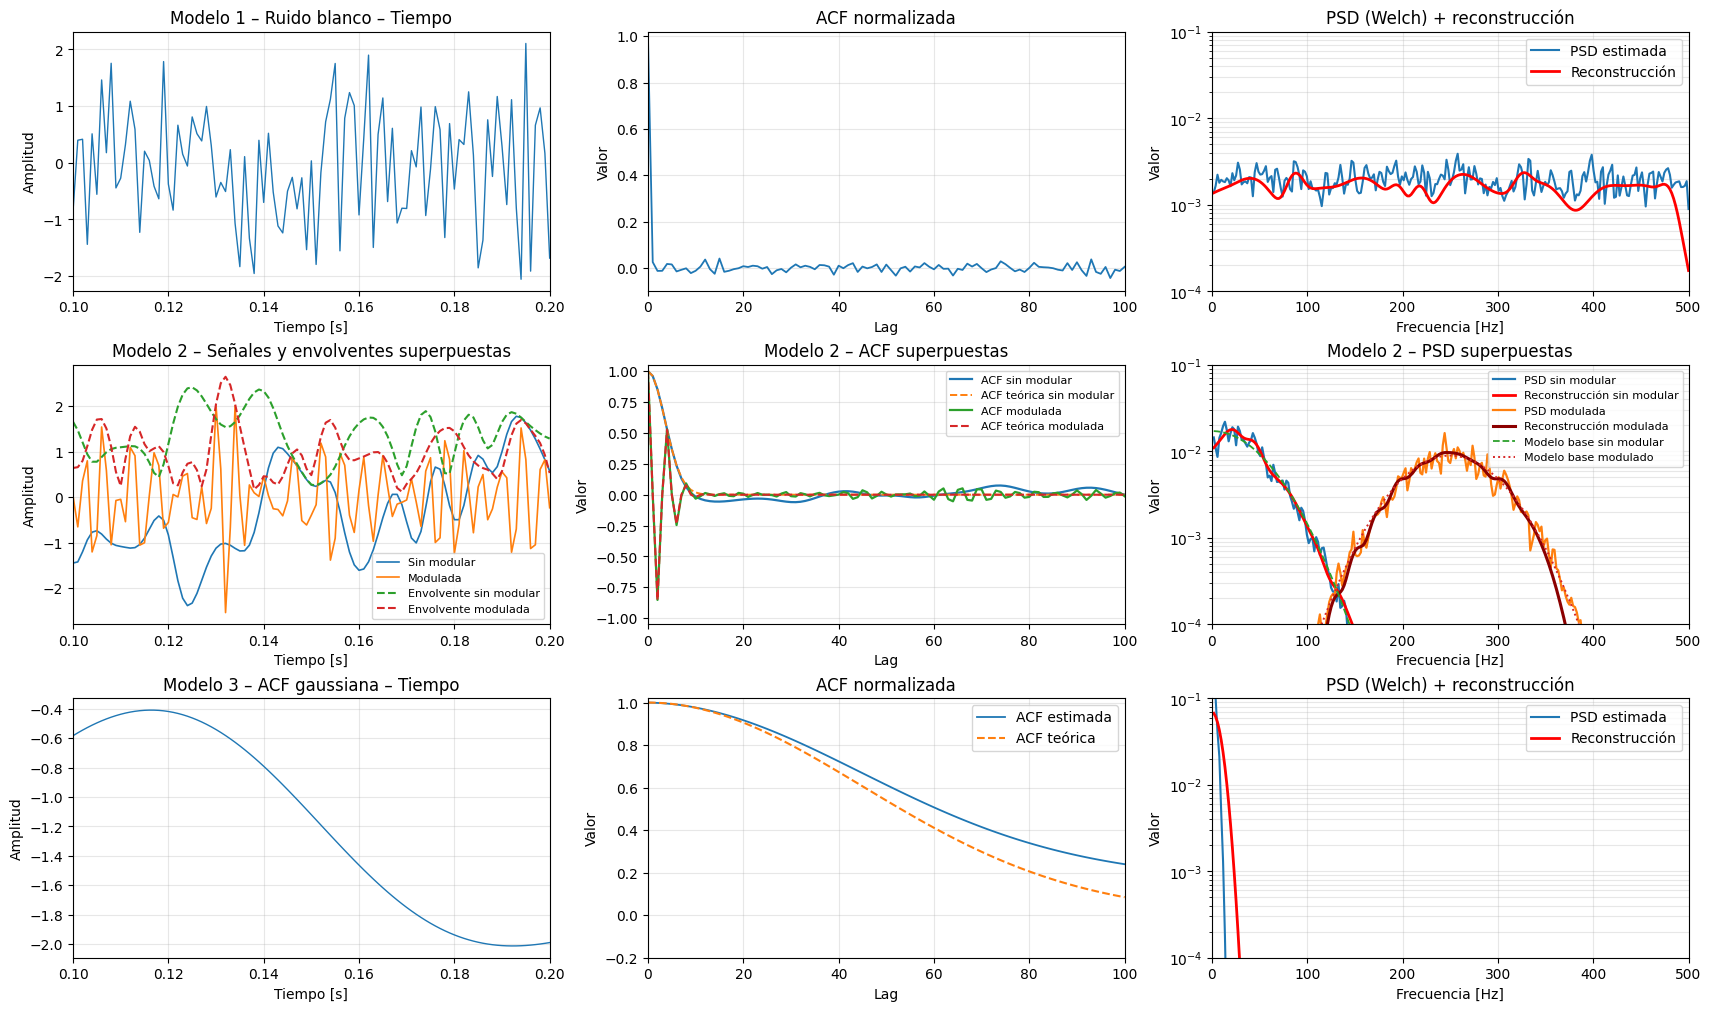

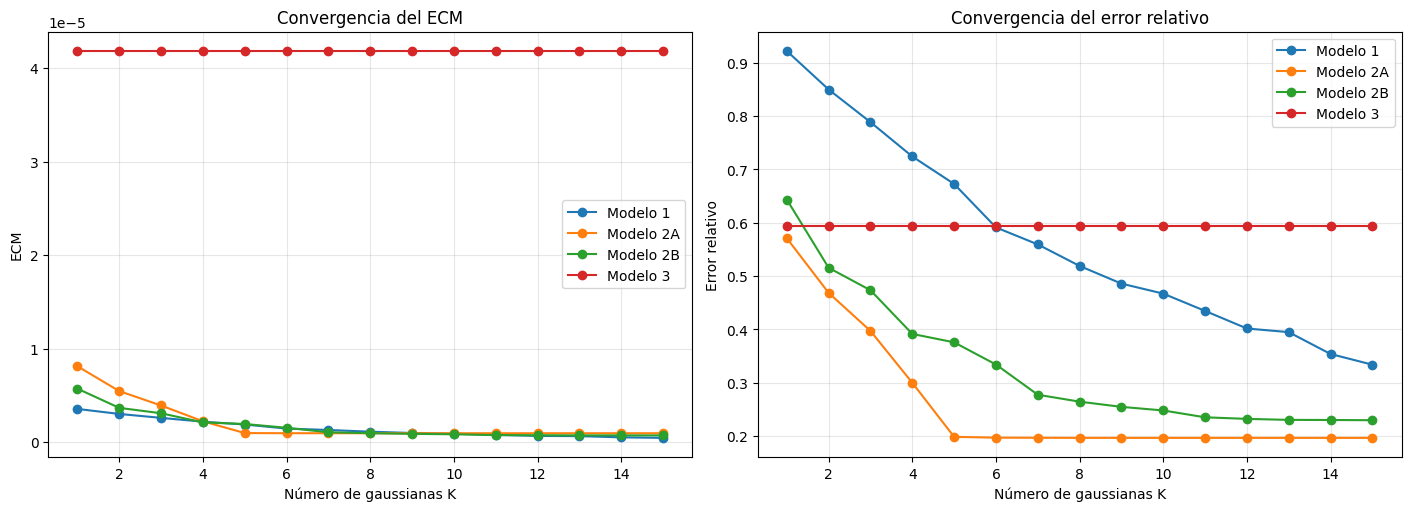

Resumen estadístico:

Modelo 1 – Ruido blanco
  media                = 0.000000
  varianza             = 1.000000
  potencia estimada    = 0.987628

Modelo 2A – Sin modular
  media                = 0.000000
  varianza             = 1.000000
  potencia estimada    = 0.971213
  mezclas necesarias   = 13

Modelo 2B – Modulada
  media                = 0.000000
  varianza             = 1.000000
  potencia estimada    = 1.011068
  frecuencia central   = 250.000 Hz
  sigma_f              = 45.000 Hz
  mezclas necesarias   = 15

Modelo 3 – ACF gaussiana
  media                = -0.000000
  varianza             = 1.000000
  potencia estimada    = 0.610502
  sigma_r              = 45.000 retardos


/tmp/ipykernel_1009/2288376916.py:435: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  potencia estimada    = {np.trapz(P1, f1):.6f}\n")
/tmp/ipykernel_1009/2288376916.py:440: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  potencia estimada    = {np.trapz(P2_sin, f2_sin):.6f}")
/tmp/ipykernel_1009/2288376916.py:446: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  potencia estimada    = {np.trapz(P2, f2):.6f}")
/tmp/ipykernel_1009/2288376916.py:454: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  potencia estimada    = {np.trapz(P3, f3):.6f}")


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, hilbert
from scipy.optimize import nnls

# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================
np.random.seed(7)

N = 4096
fs = 1000.0
mu = 0.0
varianza_objetivo = 1.0
sigma_objetivo = np.sqrt(varianza_objetivo)

t = np.arange(N) / fs

# Ventana temporal para visualizar mejor las señales
t_ini = 0.1
t_fin = 0.2
mask_t = (t >= t_ini) & (t <= t_fin)

# Parámetros gaussianos
sigma_f = 45.0
f_centro = fs / 4
sigma_r = 45.0

# Parámetros para la reconstrucción con mezclas gaussianas
K_MAX = 15
NUM_CENTROS = 24
NUM_SIGMAS = 10
SIGMA_MIN = 8.0
SIGMA_MAX = 120.0

# =========================================================
# FUNCIONES AUXILIARES
# =========================================================
def normalizar_media_varianza(x, media=0.0, varianza=1.0):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)
    std = np.std(x)
    if std < 1e-12:
        raise ValueError("La desviación estándar es demasiado pequeña para normalizar.")
    return x / std * np.sqrt(varianza) + media

def estimar_psd_welch(x, fs, nperseg=512):
    f, Pxx = welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend="constant",
        scaling="density",
        return_onesided=True,
    )
    return f, Pxx

def autocorrelacion_normalizada_positiva(x):
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)
    r = np.correlate(x, x, mode="full")
    centro = len(r) // 2
    r = r[centro:]
    if np.abs(r[0]) < 1e-14:
        raise ValueError("No se puede normalizar la autocorrelación porque r[0] es casi cero.")
    r = r / r[0]
    lags = np.arange(len(r))
    return lags, r

def gaussiana_1d(x, mu_g, sigma_g):
    return np.exp(-0.5 * ((x - mu_g) / sigma_g) ** 2)

def envolvente(x):
    return np.abs(hilbert(x))

# =========================================================
# DICCIONARIO DE MEZCLAS GAUSSIANAS
# =========================================================
def construir_diccionario_mezclas(frecuencias, num_centros=24, num_sigmas=10, sigma_min=8.0, sigma_max=120.0):
    fmax = np.max(frecuencias)
    centros = np.linspace(0.0, fmax, num_centros)
    sigmas = np.linspace(sigma_min, sigma_max, num_sigmas)

    columnas = []
    parametros = []

    for mu_k in centros:
        for sigma_k in sigmas:
            columnas.append(gaussiana_1d(frecuencias, mu_k, sigma_k))
            parametros.append((mu_k, sigma_k))

    D = np.column_stack(columnas)
    return D, parametros

def reconstruir_psd_mezcla_gaussiana(frecuencias, Pxx, K_max=15, num_centros=24, num_sigmas=10, sigma_min=8.0, sigma_max=120.0):
    frecuencias = np.asarray(frecuencias, dtype=np.float64)
    Pxx = np.asarray(Pxx, dtype=np.float64)

    D, params = construir_diccionario_mezclas(
        frecuencias,
        num_centros=num_centros,
        num_sigmas=num_sigmas,
        sigma_min=sigma_min,
        sigma_max=sigma_max,
    )

    normas = np.linalg.norm(D, axis=0) + 1e-14
    Dn = D / normas

    pesos_norm_all, _ = nnls(Dn, Pxx)
    pesos_all = pesos_norm_all / normas

    ranking = np.argsort(pesos_all)[::-1]

    errores_mse = []
    errores_rel = []
    reconstrucciones = []
    componentes = []

    for K in range(1, K_max + 1):
        idx = ranking[:K]
        Dk = D[:, idx]
        pesos_k = pesos_all[idx]

        Pxx_hat = Dk @ pesos_k

        mse = np.mean((Pxx - Pxx_hat) ** 2)
        err_rel = np.linalg.norm(Pxx - Pxx_hat) / (np.linalg.norm(Pxx) + 1e-14)

        errores_mse.append(mse)
        errores_rel.append(err_rel)
        reconstrucciones.append(Pxx_hat)
        componentes.append({
            "indices": idx,
            "pesos": pesos_k,
            "parametros": [params[i] for i in idx]
        })

    mejor_idx = int(np.argmin(errores_rel))

    return {
        "errores_mse": np.array(errores_mse),
        "errores_rel": np.array(errores_rel),
        "reconstrucciones": reconstrucciones,
        "componentes": componentes,
        "mejor_K": mejor_idx + 1,
        "mejor_reconstruccion": reconstrucciones[mejor_idx],
        "mejores_componentes": componentes[mejor_idx],
    }

# =========================================================
# MODELO 1: RUIDO BLANCO
# =========================================================
x1 = np.random.normal(loc=mu, scale=sigma_objetivo, size=N)
x1 = normalizar_media_varianza(x1, media=0.0, varianza=1.0)

# =========================================================
# MODELO 2A: CAMPANA DE GAUSS SIN MODULAR
# =========================================================
f_fft = np.fft.fftfreq(N, d=1/fs)
psd_base_centrada_0 = np.exp(-0.5 * (f_fft / sigma_f) ** 2)

W0 = np.fft.fft(np.random.normal(0, 1, N))
X2_sin_mod = W0 * np.sqrt(psd_base_centrada_0)
x2_sin_mod = np.fft.ifft(X2_sin_mod).real
x2_sin_mod = normalizar_media_varianza(x2_sin_mod, media=0.0, varianza=1.0)

# =========================================================
# MODELO 2B: CAMPANA DE GAUSS MODULADA
# =========================================================
psd_objetivo_completa = (
    np.exp(-0.5 * ((f_fft - f_centro) / sigma_f) ** 2) +
    np.exp(-0.5 * ((f_fft + f_centro) / sigma_f) ** 2)
)

W = np.fft.fft(np.random.normal(0, 1, N))
X2 = W * np.sqrt(psd_objetivo_completa)
x2 = np.fft.ifft(X2).real
x2 = normalizar_media_varianza(x2, media=0.0, varianza=1.0)

# =========================================================
# MODELO 3: RUIDO CON ACF GAUSSIANA
# =========================================================
psd_para_acf_gauss = np.exp(-2.0 * (np.pi**2) * ((sigma_r / fs) ** 2) * (f_fft ** 2))

W3 = np.fft.fft(np.random.normal(0, 1, N))
X3 = W3 * np.sqrt(psd_para_acf_gauss)
x3 = np.fft.ifft(X3).real
x3 = normalizar_media_varianza(x3, media=0.0, varianza=1.0)

# =========================================================
# ENVOLVENTES
# =========================================================
env_x2_sin = envolvente(x2_sin_mod)
env_x2 = envolvente(x2)

# =========================================================
# PSD ESTIMADAS
# =========================================================
f1, P1 = estimar_psd_welch(x1, fs)
f2_sin, P2_sin = estimar_psd_welch(x2_sin_mod, fs)
f2, P2 = estimar_psd_welch(x2, fs)
f3, P3 = estimar_psd_welch(x3, fs)

# PSD base teórica sin modular
psd_base_0_pos = np.exp(-0.5 * (f2_sin / sigma_f) ** 2)
psd_base_0_pos *= np.trapz(P2_sin, f2_sin) / (np.trapz(psd_base_0_pos, f2_sin) + 1e-14)

# PSD teórica modulada
psd_obj2 = np.exp(-0.5 * ((f2 - f_centro) / sigma_f) ** 2)
psd_obj2 *= np.trapz(P2, f2) / (np.trapz(psd_obj2, f2) + 1e-14)

# =========================================================
# AUTOCORRELACIONES
# =========================================================
lags1, r1 = autocorrelacion_normalizada_positiva(x1)
lags2_sin, r2_sin = autocorrelacion_normalizada_positiva(x2_sin_mod)
lags2, r2 = autocorrelacion_normalizada_positiva(x2)
lags3, r3 = autocorrelacion_normalizada_positiva(x3)

# ACF teórica sin modular
lags_teo2_sin = np.arange(len(r2_sin))
sigma_k_sin = fs / (2 * np.pi * sigma_f)
r2_sin_teorica = np.exp(-0.5 * (lags_teo2_sin / sigma_k_sin) ** 2)
r2_sin_teorica = r2_sin_teorica / r2_sin_teorica[0]

# ACF teórica modulada
lags_teo2 = np.arange(len(r2))
sigma_k_mod = fs / (2 * np.pi * sigma_f)
r2_teorica = np.exp(-0.5 * (lags_teo2 / sigma_k_mod) ** 2) * np.cos(2 * np.pi * f_centro * lags_teo2 / fs)
r2_teorica = r2_teorica / r2_teorica[0]

# ACF teórica del modelo 3
lags_teo3 = np.arange(len(r3))
r3_teorica = np.exp(-0.5 * (lags_teo3 / sigma_r) ** 2)

# =========================================================
# RECONSTRUCCIÓN DE PSD CON MEZCLAS GAUSSIANAS
# =========================================================
rec1 = reconstruir_psd_mezcla_gaussiana(
    f1, P1, K_max=K_MAX, num_centros=NUM_CENTROS, num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX
)
rec2_sin = reconstruir_psd_mezcla_gaussiana(
    f2_sin, P2_sin, K_max=K_MAX, num_centros=NUM_CENTROS, num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX
)
rec2 = reconstruir_psd_mezcla_gaussiana(
    f2, P2, K_max=K_MAX, num_centros=NUM_CENTROS, num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX
)
rec3 = reconstruir_psd_mezcla_gaussiana(
    f3, P3, K_max=K_MAX, num_centros=NUM_CENTROS, num_sigmas=NUM_SIGMAS,
    sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX
)

P1_rec = rec1["mejor_reconstruccion"]
P2_sin_rec = rec2_sin["mejor_reconstruccion"]
P2_rec = rec2["mejor_reconstruccion"]
P3_rec = rec3["mejor_reconstruccion"]

# =========================================================
# INFORMACIÓN
# =========================================================
print("Resumen de reconstrucción con mezclas gaussianas:\n")
for nombre, rec in zip(
    ["Modelo 1 – Ruido blanco", "Modelo 2A – Sin modular", "Modelo 2B – Modulada", "Modelo 3 – ACF gaussiana"],
    [rec1, rec2_sin, rec2, rec3]
):
    print(nombre)
    print(f"  Mejor K = {rec['mejor_K']}")
    print(f"  Error relativo mínimo = {rec['errores_rel'][rec['mejor_K'] - 1]:.6f}")
    print()

# =========================================================
# RANGO DE VISUALIZACIÓN
# =========================================================
mask1 = f1 > 0
mask2_sin = f2_sin > 0
mask2 = f2 > 0
mask3 = f3 > 0

max_lag_plot = 100
lags1_plot = lags1[:max_lag_plot + 1]
lags2_sin_plot = lags2_sin[:max_lag_plot + 1]
lags2_plot = lags2[:max_lag_plot + 1]
lags3_plot = lags3[:max_lag_plot + 1]

r1_plot = r1[:max_lag_plot + 1]
r2_sin_plot = r2_sin[:max_lag_plot + 1]
r2_plot = r2[:max_lag_plot + 1]
r3_plot = r3[:max_lag_plot + 1]
r2_sin_teorica_plot = r2_sin_teorica[:max_lag_plot + 1]
r2_teorica_plot = r2_teorica[:max_lag_plot + 1]
r3_teorica_plot = r3_teorica[:max_lag_plot + 1]

# =========================================================
# GRÁFICAS PRINCIPALES
# =========================================================
fig, axes = plt.subplots(3, 3, figsize=(17, 10), constrained_layout=True)

# FILA 1
axes[0, 0].plot(t[mask_t], x1[mask_t], linewidth=1.0)
axes[0, 0].set_title("Modelo 1 – Ruido blanco – Tiempo")
axes[0, 0].set_xlabel("Tiempo [s]")
axes[0, 0].set_ylabel("Amplitud")
axes[0, 0].set_xlim(t_ini, t_fin)
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(lags1_plot, r1_plot, linewidth=1.3)
axes[0, 1].set_title("ACF normalizada")
axes[0, 1].set_xlabel("Lag")
axes[0, 1].set_ylabel("Valor")
axes[0, 1].set_xlim(0, 100)
axes[0, 1].set_ylim(-0.1, 1.02)
axes[0, 1].grid(alpha=0.3)

axes[0, 2].semilogy(f1[mask1], P1[mask1], linewidth=1.5, label="PSD estimada")
axes[0, 2].semilogy(f1[mask1], P1_rec[mask1], color="red", linewidth=2.0, label="Reconstrucción")
axes[0, 2].set_title("PSD (Welch) + reconstrucción")
axes[0, 2].set_xlabel("Frecuencia [Hz]")
axes[0, 2].set_ylabel("Valor")
axes[0, 2].set_xlim(0, fs / 2)
axes[0, 2].set_ylim(1e-4, 1e-1)
axes[0, 2].grid(alpha=0.3, which="both")
axes[0, 2].legend()

# FILA 2
axes[1, 0].plot(t[mask_t], x2_sin_mod[mask_t], linewidth=1.2, label="Sin modular")
axes[1, 0].plot(t[mask_t], x2[mask_t], linewidth=1.2, label="Modulada")
axes[1, 0].plot(t[mask_t], env_x2_sin[mask_t], "--", linewidth=1.5, label="Envolvente sin modular")
axes[1, 0].plot(t[mask_t], env_x2[mask_t], "--", linewidth=1.5, label="Envolvente modulada")
axes[1, 0].set_title("Modelo 2 – Señales y envolventes superpuestas")
axes[1, 0].set_xlabel("Tiempo [s]")
axes[1, 0].set_ylabel("Amplitud")
axes[1, 0].set_xlim(t_ini, t_fin)
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(lags2_sin_plot, r2_sin_plot, linewidth=1.6, label="ACF sin modular")
axes[1, 1].plot(lags2_sin_plot, r2_sin_teorica_plot, "--", linewidth=1.4, label="ACF teórica sin modular")
axes[1, 1].plot(lags2_plot, r2_plot, linewidth=1.6, label="ACF modulada")
axes[1, 1].plot(lags2_plot, r2_teorica_plot, "--", linewidth=1.5, label="ACF teórica modulada")
axes[1, 1].set_title("Modelo 2 – ACF superpuestas")
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylabel("Valor")
axes[1, 1].set_xlim(0, 100)
axes[1, 1].set_ylim(-1.05, 1.05)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend(fontsize=8)

axes[1, 2].semilogy(f2_sin[mask2_sin], P2_sin[mask2_sin], linewidth=1.6, label="PSD sin modular")
axes[1, 2].semilogy(f2_sin[mask2_sin], P2_sin_rec[mask2_sin], color="red", linewidth=2.0, label="Reconstrucción sin modular")
axes[1, 2].semilogy(f2[mask2], P2[mask2], linewidth=1.6, label="PSD modulada")
axes[1, 2].semilogy(f2[mask2], P2_rec[mask2], color="darkred", linewidth=2.2, label="Reconstrucción modulada")
axes[1, 2].semilogy(f2_sin[mask2_sin], psd_base_0_pos[mask2_sin], "--", linewidth=1.3, label="Modelo base sin modular")
axes[1, 2].semilogy(f2[mask2], psd_obj2[mask2], ":", linewidth=1.4, label="Modelo base modulado")
axes[1, 2].set_title("Modelo 2 – PSD superpuestas")
axes[1, 2].set_xlabel("Frecuencia [Hz]")
axes[1, 2].set_ylabel("Valor")
axes[1, 2].set_xlim(0, fs / 2)
axes[1, 2].set_ylim(1e-4, 1e-1)
axes[1, 2].grid(alpha=0.3, which="both")
axes[1, 2].legend(fontsize=8)

# FILA 3
axes[2, 0].plot(t[mask_t], x3[mask_t], linewidth=1.0)
axes[2, 0].set_title("Modelo 3 – ACF gaussiana – Tiempo")
axes[2, 0].set_xlabel("Tiempo [s]")
axes[2, 0].set_ylabel("Amplitud")
axes[2, 0].set_xlim(t_ini, t_fin)
axes[2, 0].grid(alpha=0.3)

axes[2, 1].plot(lags3_plot, r3_plot, linewidth=1.3, label="ACF estimada")
axes[2, 1].plot(lags3_plot, r3_teorica_plot, "--", linewidth=1.5, label="ACF teórica")
axes[2, 1].set_title("ACF normalizada")
axes[2, 1].set_xlabel("Lag")
axes[2, 1].set_ylabel("Valor")
axes[2, 1].set_xlim(0, 100)
axes[2, 1].set_ylim(-0.2, 1.02)
axes[2, 1].grid(alpha=0.3)
axes[2, 1].legend()

axes[2, 2].semilogy(f3[mask3], P3[mask3], linewidth=1.5, label="PSD estimada")
axes[2, 2].semilogy(f3[mask3], P3_rec[mask3], color="red", linewidth=2.0, label="Reconstrucción")
axes[2, 2].set_title("PSD (Welch) + reconstrucción")
axes[2, 2].set_xlabel("Frecuencia [Hz]")
axes[2, 2].set_ylabel("Valor")
axes[2, 2].set_xlim(0, fs / 2)
axes[2, 2].set_ylim(1e-4, 1e-1)
axes[2, 2].grid(alpha=0.3, which="both")
axes[2, 2].legend()

plt.show()

# =========================================================
# GRÁFICAS DE CONVERGENCIA
# =========================================================
Ks = np.arange(1, K_MAX + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

ax[0].plot(Ks, rec1["errores_mse"], marker="o", linewidth=1.5, label="Modelo 1")
ax[0].plot(Ks, rec2_sin["errores_mse"], marker="o", linewidth=1.5, label="Modelo 2A")
ax[0].plot(Ks, rec2["errores_mse"], marker="o", linewidth=1.5, label="Modelo 2B")
ax[0].plot(Ks, rec3["errores_mse"], marker="o", linewidth=1.5, label="Modelo 3")
ax[0].set_title("Convergencia del ECM")
ax[0].set_xlabel("Número de gaussianas K")
ax[0].set_ylabel("ECM")
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(Ks, rec1["errores_rel"], marker="o", linewidth=1.5, label="Modelo 1")
ax[1].plot(Ks, rec2_sin["errores_rel"], marker="o", linewidth=1.5, label="Modelo 2A")
ax[1].plot(Ks, rec2["errores_rel"], marker="o", linewidth=1.5, label="Modelo 2B")
ax[1].plot(Ks, rec3["errores_rel"], marker="o", linewidth=1.5, label="Modelo 3")
ax[1].set_title("Convergencia del error relativo")
ax[1].set_xlabel("Número de gaussianas K")
ax[1].set_ylabel("Error relativo")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.show()

# =========================================================
# RESUMEN NUMÉRICO
# =========================================================
print("Resumen estadístico:\n")

print("Modelo 1 – Ruido blanco")
print(f"  media                = {np.mean(x1):.6f}")
print(f"  varianza             = {np.var(x1):.6f}")
print(f"  potencia estimada    = {np.trapz(P1, f1):.6f}\n")

print("Modelo 2A – Sin modular")
print(f"  media                = {np.mean(x2_sin_mod):.6f}")
print(f"  varianza             = {np.var(x2_sin_mod):.6f}")
print(f"  potencia estimada    = {np.trapz(P2_sin, f2_sin):.6f}")
print(f"  mezclas necesarias   = {rec2_sin['mejor_K']}\n")

print("Modelo 2B – Modulada")
print(f"  media                = {np.mean(x2):.6f}")
print(f"  varianza             = {np.var(x2):.6f}")
print(f"  potencia estimada    = {np.trapz(P2, f2):.6f}")
print(f"  frecuencia central   = {f_centro:.3f} Hz")
print(f"  sigma_f              = {sigma_f:.3f} Hz")
print(f"  mezclas necesarias   = {rec2['mejor_K']}\n")

print("Modelo 3 – ACF gaussiana")
print(f"  media                = {np.mean(x3):.6f}")
print(f"  varianza             = {np.var(x3):.6f}")
print(f"  potencia estimada    = {np.trapz(P3, f3):.6f}")
print(f"  sigma_r              = {sigma_r:.3f} retardos")